# 📊 Análise do Dataset OULAD — Notebook Principal

**Open University Learning Analytics Dataset (OULAD)**

Este notebook realiza uma análise acadêmica completa, estruturada e reprodutível
do dataset OULAD. Está organizado em seções que respondem a 5 perguntas de
pesquisa principais, além de análises adicionais (avaliações e segmentação com
K-Means).

> **Idiomas:** o texto explicativo está em **português** e os rótulos dos
> gráficos em **inglês** (termos originais do OULAD), para facilitar a leitura
> por uma equipe multilíngue.

**Reprodutibilidade:** todo o código usa `random_state=42`, caminhos relativos
com `pathlib` e funções reutilizáveis do pacote `src/`. O notebook deve poder
ser executado do início ao fim com *Run All Cells* sem erros.

## 0. Configuração inicial

**O quê:** importamos as bibliotecas, configuramos o estilo dos gráficos,
fixamos a semente aleatória e preparamos o acesso aos módulos do pacote `src/`.

**Por quê:** centralizar a configuração garante consistência visual e
reprodutibilidade em toda a análise. Iniciamos também o cronômetro global para
reportar o tempo total de execução ao final.

In [1]:
import time
_t_inicio = time.time()  # cronômetro global

import sys
from pathlib import Path

# Permite importar o pacote src/ executando a partir de notebooks/ ou da raiz.
ROOT = Path.cwd()
if (ROOT / "src").exists():
    PROJECT_ROOT = ROOT
elif (ROOT.parent / "src").exists():
    PROJECT_ROOT = ROOT.parent
else:
    raise RuntimeError("Pasta src/ não encontrada. Execute a partir da raiz do projeto ou de notebooks/.")
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import missingno as msno

from src import load_data, preprocess, visualizations as viz

# Semente global para reprodutibilidade.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Estilo de gráficos consistente.
viz.set_style()

# Dicionário para acumular achados-chave que depois alimentam o relatório.
findings = {}

print("Configuração pronta. PROJECT_ROOT =", PROJECT_ROOT)
print("pandas", pd.__version__, "| numpy", np.__version__)

Configuração pronta. PROJECT_ROOT = C:\Users\KELLY\Downloads\OULAD\oulad-analysis
pandas 2.2.3 | numpy 2.2.6


## 1. Verificação de arquivos e carregamento dos dados

**O quê:** verificamos que os 7 CSV existam em `data/raw/` e, se tudo estiver
correto, os carregamos em um dicionário de DataFrames.

**Por quê:** falhar cedo com uma mensagem clara é melhor do que um erro críptico
no meio da análise. O carregamento usa dtypes otimizados para `studentVle.csv`
(~10.6M de linhas) e assim reduzir o consumo de memória.

In [2]:
# Verificação: lança FileNotFoundError claro se faltar algum CSV.
load_data.check_files()

[OK] Los 7 CSV están presentes en: C:\Users\KELLY\Downloads\OULAD\oulad-analysis\data\raw


In [3]:
# Carregamento dos 7 CSV. studentVle leva alguns segundos por causa do tamanho.
data = load_data.load_all()

[OK] Los 7 CSV están presentes en: C:\Users\KELLY\Downloads\OULAD\oulad-analysis\data\raw
[cargado] courses                shape=(22, 3)            mem=    0.0 MB
[cargado] assessments            shape=(206, 6)           mem=    0.0 MB
[cargado] vle                    shape=(6364, 6)          mem=    1.1 MB


[cargado] studentInfo            shape=(32593, 12)        mem=   16.3 MB
[cargado] studentRegistration    shape=(32593, 5)         mem=    4.0 MB


[cargado] studentAssessment      shape=(173912, 5)        mem=    6.6 MB


[cargado] studentVle             shape=(10655280, 6)      mem=  142.3 MB


### 1.1 Inspeção inicial de cada tabela

Imprimimos shape, dtypes e primeiras linhas de cada DataFrame para entender a
estrutura do dataset.

In [4]:
load_data.inspect_all(data, n_rows=3)

TABLA: courses
Shape: 22 filas x 3 columnas

Dtypes:
code_module                   object
code_presentation             object
module_presentation_length     int64

Primeras 3 filas:
  code_module code_presentation  module_presentation_length
0         AAA             2013J                         268
1         AAA             2014J                         269
2         BBB             2013J                         268

TABLA: assessments
Shape: 206 filas x 6 columnas

Dtypes:
code_module           object
code_presentation     object
id_assessment          int64
assessment_type       object
date                 float64
weight               float64

Primeras 3 filas:
  code_module code_presentation  id_assessment assessment_type   date  weight
0         AAA             2013J           1752             TMA   19.0    10.0
1         AAA             2013J           1753             TMA   54.0    20.0
2         AAA             2013J           1754             TMA  117.0    20.0

TABLA: vle
S

## 2. Exploração inicial (EDA)

**O quê:** para cada um dos 7 DataFrames calculamos shape, dtypes,
`describe()`, porcentagem de nulos por coluna, número de duplicados e, para as
colunas categóricas, `value_counts()` com porcentagens.

**Por quê:** a EDA revela problemas de qualidade (nulos, duplicados, tipos
incorretos) que condicionam as decisões de limpeza do Passo 3.

In [5]:
def eda_resumen(nombre, df, max_cat_unique=15):
    print("=" * 90)
    print(f"TABELA: {nombre}  ->  {df.shape[0]:,} linhas x {df.shape[1]} colunas")
    print("=" * 90)

    # Nulos por coluna em porcentagem.
    nulos = (df.isna().mean() * 100).round(2)
    nulos = nulos[nulos > 0]
    if len(nulos):
        print("\nNulos por coluna (%):")
        print(nulos.to_string())
    else:
        print("\nNulos por coluna (%): nenhuma coluna com nulos")

    # Duplicados.
    print(f"\nLinhas duplicadas: {df.duplicated().sum():,}")

    # describe (numéricas).
    num = df.select_dtypes(include=[np.number])
    if num.shape[1]:
        print("\nDescribe (numéricas):")
        with pd.option_context("display.width", 160, "display.max_columns", None):
            print(num.describe().round(2).to_string())

    # value_counts das categóricas com poucas categorias.
    cat = df.select_dtypes(include=["object", "category"])
    for c in cat.columns:
        nun = df[c].nunique(dropna=True)
        if nun <= max_cat_unique:
            print(f"\nvalue_counts de '{c}' ({nun} categorias):")
            vc = df[c].value_counts(dropna=False)
            pct = (vc / len(df) * 100).round(2)
            print(pd.DataFrame({"conteo": vc, "porcentaje": pct}).to_string())
    print()


for nombre, df in data.items():
    eda_resumen(nombre, df)

TABELA: courses  ->  22 linhas x 3 colunas

Nulos por coluna (%): nenhuma coluna com nulos

Linhas duplicadas: 0

Describe (numéricas):
       module_presentation_length
count                       22.00
mean                       255.55
std                         13.65
min                        234.00
25%                        241.00
50%                        261.50
75%                        268.00
max                        269.00

value_counts de 'code_module' (7 categorias):
             conteo  porcentaje
code_module                    
BBB               4       18.18
FFF               4       18.18
DDD               4       18.18
EEE               3       13.64
GGG               3       13.64
CCC               2        9.09
AAA               2        9.09

value_counts de 'code_presentation' (4 categorias):
                   conteo  porcentaje
code_presentation                    
2014J                   7       31.82
2013J                   6       27.27
2014B             


value_counts de 'code_presentation' (4 categorias):
                   conteo  porcentaje
code_presentation                    
2014J               11260       34.55
2013J                8845       27.14
2014B                7804       23.94
2013B                4684       14.37



value_counts de 'gender' (2 categorias):
        conteo  porcentaje
gender                    
M        17875       54.84
F        14718       45.16

value_counts de 'region' (13 categorias):
                      conteo  porcentaje
region                                  
Scotland                3446       10.57
East Anglian Region     3340       10.25
London Region           3216        9.87
South Region            3092        9.49
North Western Region    2906        8.92
West Midlands Region    2582        7.92
South West Region       2436        7.47
East Midlands Region    2365        7.26
South East Region       2111        6.48
Wales                   2086        6.40
Yorkshire Region        2006        6.15
North Region            1823        5.59
Ireland                 1184        3.63

value_counts de 'highest_education' (5 categorias):
                             conteo  porcentaje
highest_education                              
A Level or Equivalent         14045       4


Linhas duplicadas: 0

Describe (numéricas):
       id_student  date_registration  date_unregistration
count    32593.00           32548.00             10072.00
mean    706687.67             -69.41                49.76
std     549167.31              49.26                82.46
min       3733.00            -322.00              -365.00
25%     508573.00            -100.00                -2.00
50%     590310.00             -57.00                27.00
75%     644453.00             -29.00               109.00
max    2716795.00             167.00               444.00

value_counts de 'code_module' (7 categorias):
             conteo  porcentaje
code_module                    
BBB            7909       24.27
FFF            7762       23.81
DDD            6272       19.24
CCC            4434       13.60
EEE            2934        9.00
GGG            2534        7.77
AAA             748        2.29

value_counts de 'code_presentation' (4 categorias):
                   conteo  porcentaje
code_pr


Nulos por coluna (%): nenhuma coluna com nulos



Linhas duplicadas: 787,170

Describe (numéricas):


        id_student      id_site         date    sum_click
count  10655280.00  10655280.00  10655280.00  10655280.00
mean     733333.57    738323.42        95.17         3.72
std      582705.98    131219.62        76.07         8.85
min        6516.00    526721.00       -25.00         1.00
25%      507743.00    673519.00        25.00         1.00
50%      588236.00    730069.00        86.00         2.00
75%      646484.00    877030.00       156.00         3.00
max     2698588.00   1049562.00       269.00      6977.00

value_counts de 'code_module' (7 categorias):
              conteo  porcentaje
code_module                     
FFF          4014499       37.68
DDD          2166486       20.33
BBB          1567564       14.71
CCC          1207827       11.34
EEE           961433        9.02
GGG           387173        3.63
AAA           350298        3.29



value_counts de 'code_presentation' (4 categorias):
                    conteo  porcentaje
code_presentation                     
2014J              3619452       33.97
2013J              2988784       28.05
2014B              2160176       20.27
2013B              1886868       17.71



### 2.1 Matriz de valores nulos (missingno)

Visualizamos os nulos das tabelas com dados faltantes relevantes:
`studentInfo` (imd_band) e `studentRegistration` (date_unregistration).
Salvamos a figura em `outputs/figures/missing_values.png`.

[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\missing_values.png


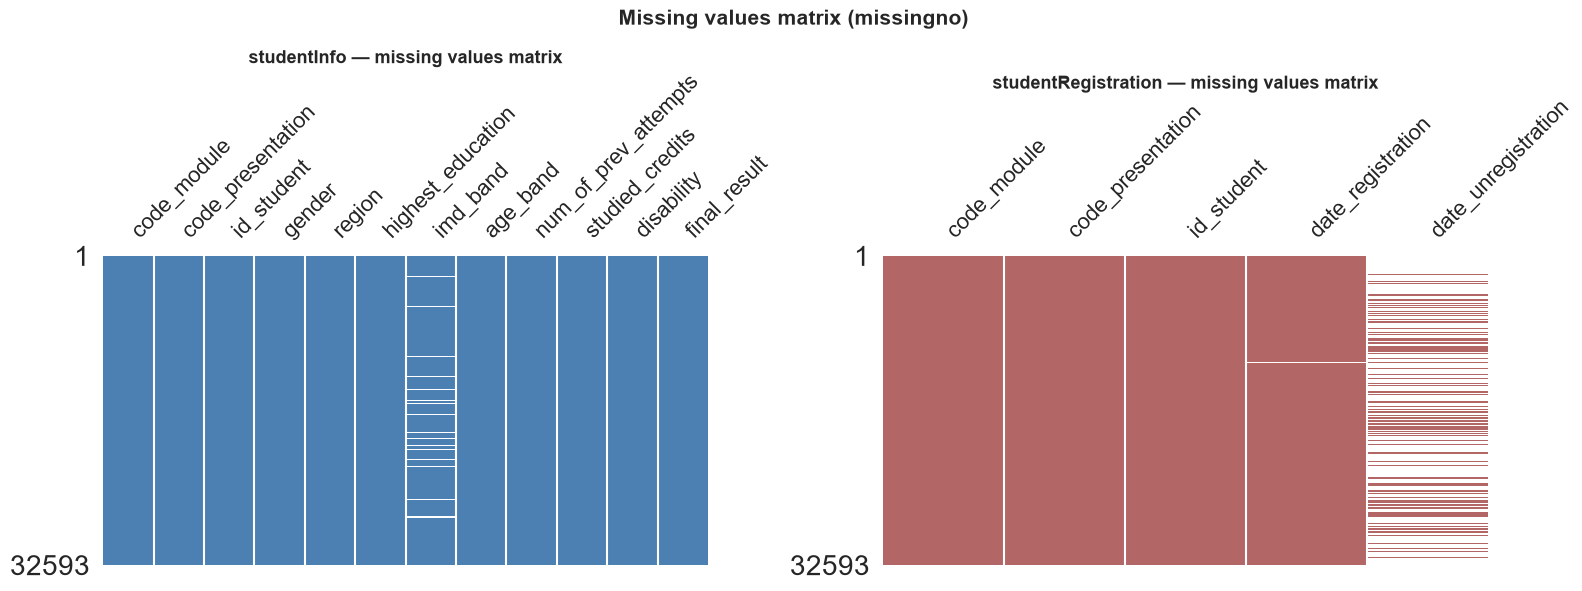

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
msno.matrix(data["studentInfo"], ax=axes[0], sparkline=False, color=(0.3, 0.5, 0.7))
axes[0].set_title("studentInfo — missing values matrix", fontsize=13, fontweight="bold")
msno.matrix(data["studentRegistration"], ax=axes[1], sparkline=False, color=(0.7, 0.4, 0.4))
axes[1].set_title("studentRegistration — missing values matrix", fontsize=13, fontweight="bold")
fig.suptitle("Missing values matrix (missingno)", fontsize=15, fontweight="bold")
fig.tight_layout()
viz.save_fig(fig, "missing_values.png")
plt.show()

## 3. Limpeza e pré-processamento

**O quê:** aplicamos o pipeline de `src/preprocess.py`:
1. **studentInfo** — `final_result` para a coluna `resultado` (Pass / Fail /
   Withdrawn / Distinction), conversão para `Categorical`, normalização e
   imputação de `imd_band` com a moda.
2. **studentAssessment** — `score` para numérico, marca `no_submitted` para
   `is_banked == 1` ou `score` nulo.
3. **studentVle** — cliques totais e dias ativos por estudante.
4. **studentRegistration** — datas para numérico e `dias_hasta_retiro`.
5. **df_master** — left join de studentInfo + studentRegistration + cliques +
   média de score.

**Por quê:** um único DataFrame mestre limpo simplifica todas as análises
posteriores e evita junções repetidas.

**Decisão sobre nulos:** `imd_band` é imputado com a moda (variável categórica,
~3.4% de nulos). `date_unregistration` é deixado como nulo de forma intencional:
um nulo significa que o estudante **não desistiu**, portanto imputá-lo
introduziria viés.

In [7]:
info = preprocess.clean_student_info(data["studentInfo"])
assessment = preprocess.clean_student_assessment(data["studentAssessment"])
registration = preprocess.clean_student_registration(data["studentRegistration"])
clicks = preprocess.aggregate_clicks(data["studentVle"])
scores = preprocess.mean_score_per_student(assessment, data["assessments"])

df_master = preprocess.build_master(info, registration, clicks, scores)
df_master = preprocess.encode_demographics(df_master)

print("\nColunas de df_master:")
print(df_master.dtypes.to_string())
df_master.head()

[imd_band] Imputados 1,111 nulos con la moda = '20-30%'
[studentAssessment] Marcados 2,081 registros como 'no_submitted' (1.20%)


[studentVle] Clics agregados para 29,228 combinaciones estudiante-módulo-presentación
[scores] Score promedio calculado para 25,557 estudiantes


[df_master] Construido con shape=(32593, 19)

Colunas de df_master:
code_module                    object
code_presentation              object
id_student                      int64
gender                       category
region                         object
highest_education            category
imd_band                     category
age_band                     category
num_of_prev_attempts            int64
studied_credits                 int64
disability                   category
final_result                   object
resultado                    category
date_registration             float64
date_unregistration           float64
dias_hasta_retiro             float64
clicks_totales                  int64
dias_activos                    int64
score_promedio                float64
highest_education_encoded       int64
imd_band_encoded                int64
age_band_encoded                int64
gender_encoded                  int64
disability_encoded              int64
resultado_encoded   

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,dias_hasta_retiro,clicks_totales,dias_activos,score_promedio,highest_education_encoded,imd_band_encoded,age_band_encoded,gender_encoded,disability_encoded,resultado_encoded
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,NaN,934,40,82.0,3,9,2,1,0,2
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,NaN,1435,80,66.4,3,2,1,0,0,2
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,104.0,281,12,NaN,2,3,1,0,1,0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,NaN,2158,123,76.0,2,5,1,0,0,2
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,NaN,1034,70,54.4,1,5,0,0,0,2


## 4. Pergunta 1 — Desempenho acadêmico

**O quê:** analisamos como se distribuem os resultados finais (`resultado`),
globalmente e por módulo / apresentação.

**Por quê:** estabelece a linha de base do sucesso estudantil e permite detectar
módulos problemáticos.

Visualizações: (A) barras horizontais com contagem e %, (B) pizza, (C) heatmap
módulo × resultado, (D) barras empilhadas a 100% por módulo.

Distribuição global dos resultados:
             conteo  porcentaje
resultado                      
Distinction    3024        9.28
Pass          12361       37.93
Fail           7052       21.64
Withdrawn     10156       31.16


[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p1_A_resultados_barras.png


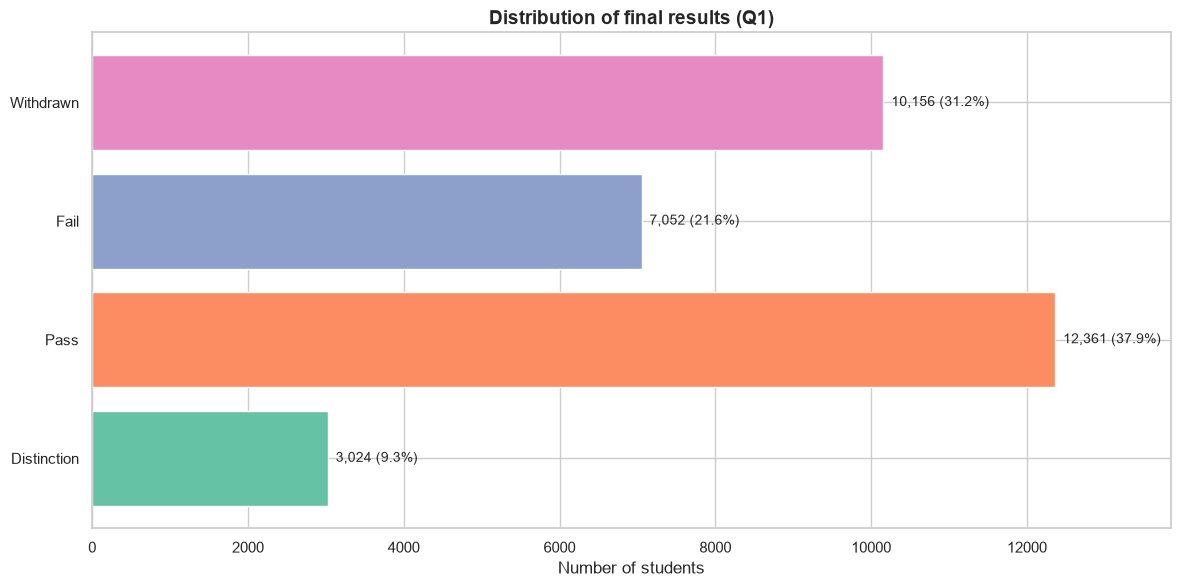

In [8]:
from src.preprocess import RESULT_ORDER

# Frequência e porcentagem global.
res_counts = df_master["resultado"].value_counts().reindex(RESULT_ORDER)
res_pct = (res_counts / res_counts.sum() * 100).round(2)
print("Distribuição global dos resultados:")
print(pd.DataFrame({"conteo": res_counts, "porcentaje": res_pct}).to_string())

# A) Barras horizontais com contagem e %.
fig = viz.barh_counts_pct(df_master["resultado"], "Distribution of final results (Q1)",
                          "Number of students", order=RESULT_ORDER)
viz.save_fig(fig, "p1_A_resultados_barras.png"); plt.show()

[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p1_B_resultados_torta.png


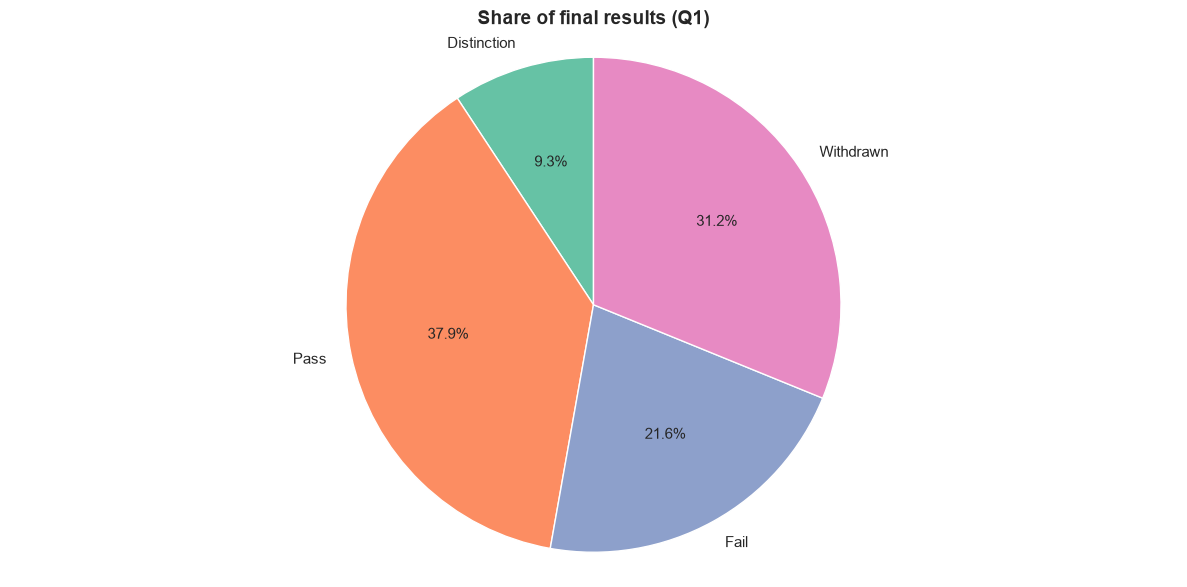

In [9]:
# B) Gráfico de pizza.
fig = viz.pie_chart(df_master["resultado"], "Share of final results (Q1)", order=RESULT_ORDER)
viz.save_fig(fig, "p1_B_resultados_torta.png"); plt.show()

[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p1_C_heatmap_modulo_resultado.png


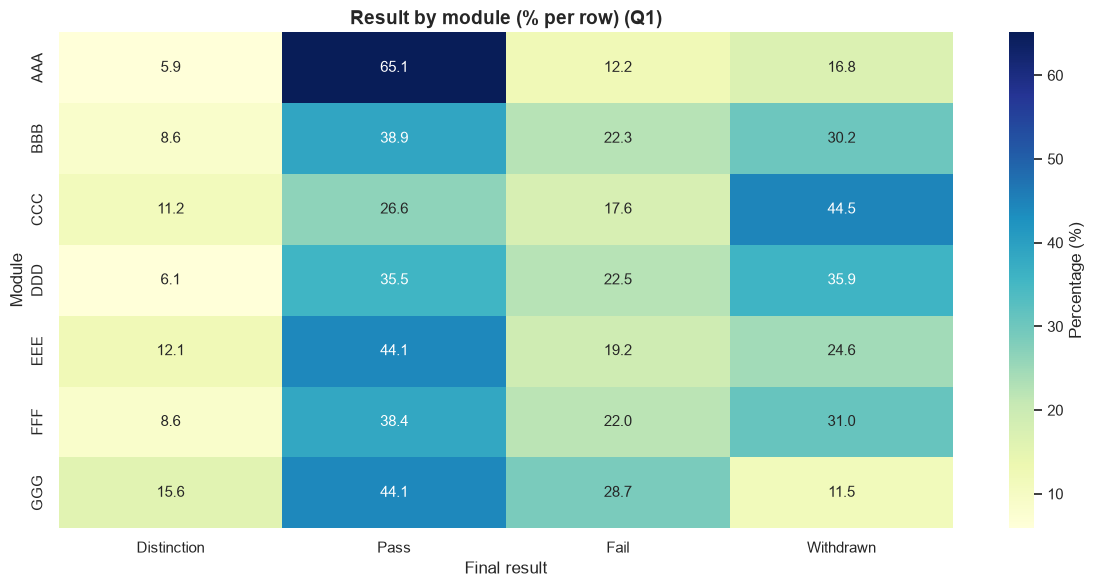

In [10]:
# C) Heatmap módulo × resultado (% por linha).
ct_mod = pd.crosstab(df_master["code_module"], df_master["resultado"])[RESULT_ORDER]
fig = viz.heatmap_pct(ct_mod, "Result by module (% per row) (Q1)",
                      "Final result", "Module", col_order=RESULT_ORDER)
viz.save_fig(fig, "p1_C_heatmap_modulo_resultado.png"); plt.show()

[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p1_D_apiladas_modulo.png


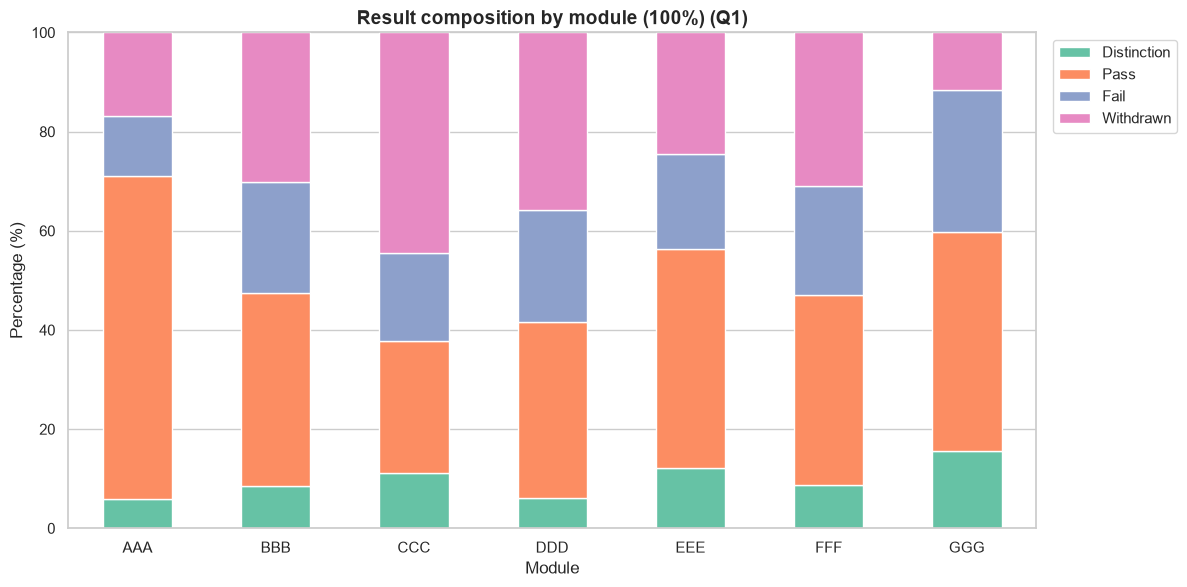

In [11]:
# D) Barras empilhadas a 100% por módulo.
fig = viz.stacked_100(ct_mod, "Result composition by module (100%) (Q1)",
                      "Module", col_order=RESULT_ORDER)
viz.save_fig(fig, "p1_D_apiladas_modulo.png"); plt.show()

In [12]:
# Distribuição por apresentação.
ct_pres = pd.crosstab(df_master["code_presentation"], df_master["resultado"])[RESULT_ORDER]
print("Resultado por apresentação (%):")
print((ct_pres.div(ct_pres.sum(axis=1), axis=0) * 100).round(1).to_string())

# Estatísticas-chave: taxa global de aprovação e módulos extremos.
tasa_aprob = res_pct["Pass"] + res_pct["Distinction"]
aprob_por_mod = ct_mod[["Pass", "Distinction"]].sum(axis=1) / ct_mod.sum(axis=1) * 100
mod_max = aprob_por_mod.idxmax(); mod_min = aprob_por_mod.idxmin()

findings["p1_tasa_aprobacion_global"] = round(float(tasa_aprob), 2)
findings["p1_modulo_mayor_aprobacion"] = (mod_max, round(float(aprob_por_mod.max()), 2))
findings["p1_modulo_menor_aprobacion"] = (mod_min, round(float(aprob_por_mod.min()), 2))
findings["p1_dist_resultados"] = res_pct.to_dict()

print(f"\n>>> Taxa global de APROVAÇÃO (Pass + Distinction): {tasa_aprob:.2f}%")
print(f">>> Módulo com MAIOR aprovação: {mod_max} ({aprob_por_mod.max():.2f}%)")
print(f">>> Módulo com MENOR aprovação: {mod_min} ({aprob_por_mod.min():.2f}%)")

Resultado por apresentação (%):
resultado          Distinction  Pass  Fail  Withdrawn
code_presentation                                    
2013B                      7.0  37.7  26.5       28.8
2013J                      8.5  42.1  22.6       26.8
2014B                     10.0  33.0  23.5       33.5
2014J                     10.3  38.1  17.6       34.0

>>> Taxa global de APROVAÇÃO (Pass + Distinction): 47.21%
>>> Módulo com MAIOR aprovação: AAA (70.99%)
>>> Módulo com MENOR aprovação: CCC (37.84%)


### 📌 Resumo dos achados — Pergunta 1

O bloco a seguir imprime um resumo em texto claro da Pergunta 1.

In [13]:
print("RESUMO Q1 — Desempenho acadêmico")
print("-" * 60)
print(f"- Resultado mais frequente: {res_counts.idxmax()} ({res_pct.max():.1f}%).")
print(f"- Taxa global de aprovação (Pass+Distinction): {tasa_aprob:.1f}%.")
print(f"- Taxa de desistência global: {res_pct['Withdrawn']:.1f}%.")
print(f"- Módulo mais bem-sucedido: {mod_max} ({aprob_por_mod.max():.1f}% de aprovação).")
print(f"- Módulo mais problemático: {mod_min} ({aprob_por_mod.min():.1f}% de aprovação).")

RESUMO Q1 — Desempenho acadêmico
------------------------------------------------------------
- Resultado mais frequente: Pass (37.9%).
- Taxa global de aprovação (Pass+Distinction): 47.2%.
- Taxa de desistência global: 31.2%.
- Módulo mais bem-sucedido: AAA (71.0% de aprovação).
- Módulo mais problemático: CCC (37.8% de aprovação).


## 5. Pergunta 2 — Interação com o VLE

**O quê:** mais cliques no ambiente virtual de aprendizagem (VLE) se associam a
melhores resultados? Comparamos `clicks_totales` entre os 4 grupos de resultado,
aplicamos o teste de **Kruskal-Wallis** (não paramétrico, pois os cliques não
são normais) e medimos a correlação entre cliques e `score_promedio`.

**Por quê:** a atividade no VLE é um preditor precoce clássico de evasão e
desempenho; quantificá-lo justifica sistemas de alerta antecipado.

Visualizações: (A) boxplot log-Y, (B) violinplot, (C) dispersão cliques vs score
com regressão, (D) barras de média ± desvio.

In [14]:
from src.preprocess import RESULT_ORDER

# Estatísticas descritivas dos cliques por grupo de resultado.
desc_clicks = df_master.groupby("resultado", observed=True)["clicks_totales"].agg(
    ["count", "mean", "median", "std"]).reindex(RESULT_ORDER).round(1)
print("Cliques totais por resultado:")
print(desc_clicks.to_string())

# Teste de Kruskal-Wallis entre os 4 grupos.
grupos = [df_master.loc[df_master["resultado"] == r, "clicks_totales"].dropna()
          for r in RESULT_ORDER]
H, p_kw = stats.kruskal(*grupos)
print(f"\nKruskal-Wallis: H = {H:.2f}, p-valor = {p_kw:.3e}")

findings["p2_clicks_por_resultado"] = desc_clicks[["mean", "median"]].to_dict("index")
findings["p2_kruskal_H"] = round(float(H), 2)
findings["p2_kruskal_p"] = float(p_kw)

Cliques totais por resultado:
             count    mean  median     std
resultado                                 
Distinction   3024  2666.8  1896.0  2410.0
Pass         12361  1921.8  1343.0  1852.8
Fail          7052   651.9   317.0   966.9
Withdrawn    10156   314.0    89.0   608.6

Kruskal-Wallis: H = 14857.48, p-valor = 0.000e+00


C:\Users\KELLY\AppData\Local\Temp\ipykernel_29068\3162770889.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_master, x="resultado", y="clicks_totales", order=RESULT_ORDER,


[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p2_A_boxplot_clicks.png


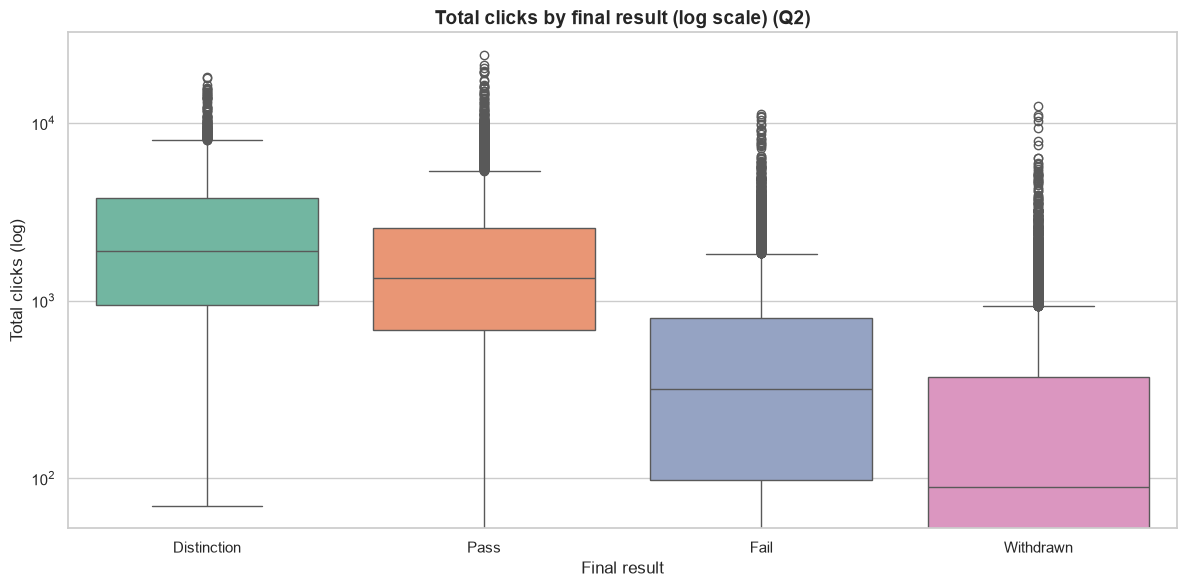

In [15]:
# A) Boxplot dos cliques por resultado (escala log em Y).
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_master, x="resultado", y="clicks_totales", order=RESULT_ORDER,
            palette="Set2", ax=ax)
ax.set_yscale("log")
ax.set_title("Total clicks by final result (log scale) (Q2)")
ax.set_xlabel("Final result"); ax.set_ylabel("Total clicks (log)")
fig.tight_layout(); viz.save_fig(fig, "p2_A_boxplot_clicks.png"); plt.show()

C:\Users\KELLY\AppData\Local\Temp\ipykernel_29068\1699459870.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="resultado", y="log_clicks", order=RESULT_ORDER,


[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p2_B_violinplot_clicks.png


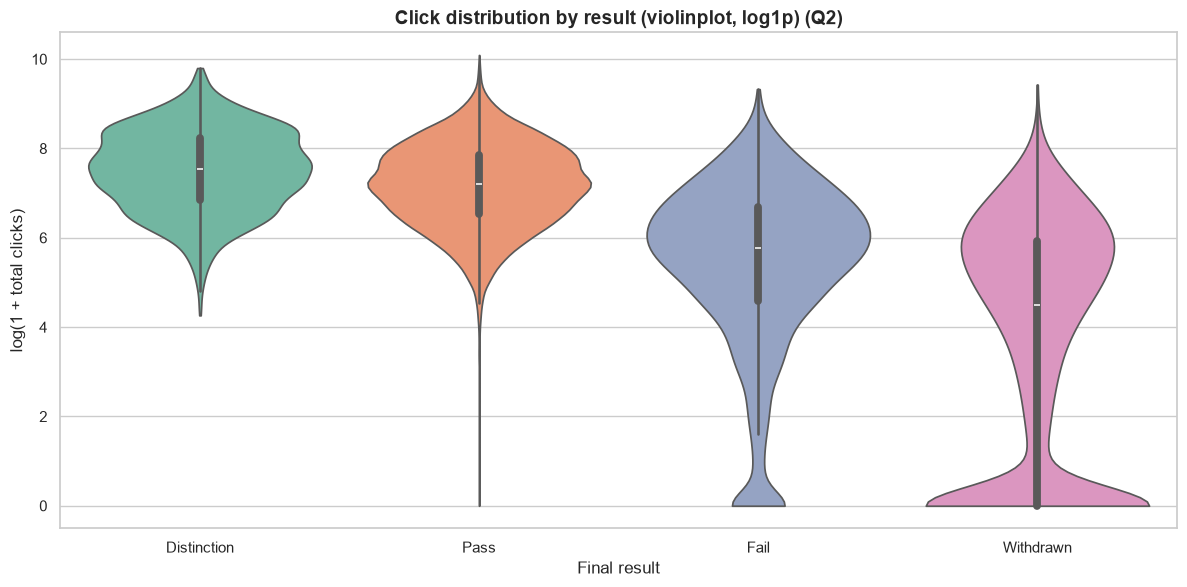

In [16]:
# B) Violinplot.
fig, ax = plt.subplots(figsize=(12, 6))
df_plot = df_master.copy()
df_plot["log_clicks"] = np.log1p(df_plot["clicks_totales"])
sns.violinplot(data=df_plot, x="resultado", y="log_clicks", order=RESULT_ORDER,
               palette="Set2", ax=ax, cut=0)
ax.set_title("Click distribution by result (violinplot, log1p) (Q2)")
ax.set_xlabel("Final result"); ax.set_ylabel("log(1 + total clicks)")
fig.tight_layout(); viz.save_fig(fig, "p2_B_violinplot_clicks.png"); plt.show()

[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p2_C_scatter_clicks_score.png


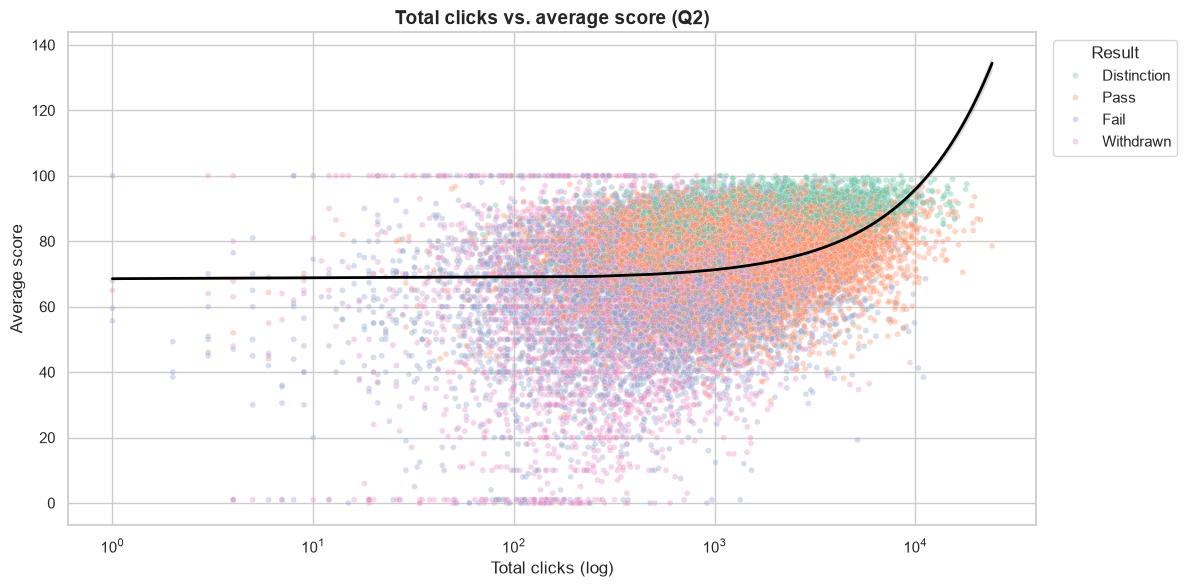

Correlação Spearman cliques vs score: rho = 0.356 (p = 0.000e+00)


In [17]:
# C) Dispersão cliques vs média de score, colorido por resultado + regressão global.
sub = df_master.dropna(subset=["score_promedio", "clicks_totales"]).copy()
sub = sub[sub["clicks_totales"] > 0]
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(data=sub, x="clicks_totales", y="score_promedio", hue="resultado",
                hue_order=RESULT_ORDER, palette="Set2", alpha=0.35, s=18, ax=ax)
sns.regplot(data=sub, x="clicks_totales", y="score_promedio", scatter=False,
            color="black", line_kws={"linewidth": 2}, ax=ax)
ax.set_xscale("log")
ax.set_title("Total clicks vs. average score (Q2)")
ax.set_xlabel("Total clicks (log)"); ax.set_ylabel("Average score")
ax.legend(title="Result", bbox_to_anchor=(1.01, 1), loc="upper left")
fig.tight_layout(); viz.save_fig(fig, "p2_C_scatter_clicks_score.png"); plt.show()

# Correlação de Spearman (robusta à não-normalidade).
rho, p_rho = stats.spearmanr(sub["clicks_totales"], sub["score_promedio"])
print(f"Correlação Spearman cliques vs score: rho = {rho:.3f} (p = {p_rho:.3e})")
findings["p2_spearman_rho"] = round(float(rho), 3)

[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p2_D_barras_media_clicks.png


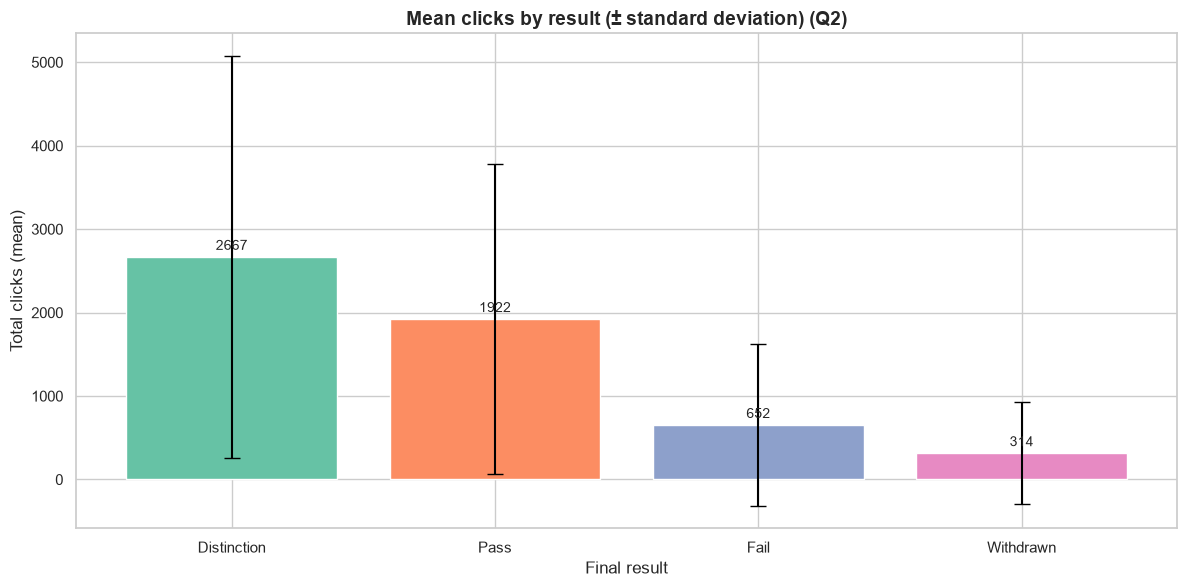

In [18]:
# D) Barras com média de cliques ± desvio.
fig, ax = plt.subplots(figsize=(12, 6))
medias = desc_clicks["mean"]; errs = desc_clicks["std"]
colors = sns.color_palette("Set2", len(RESULT_ORDER))
ax.bar(medias.index.astype(str), medias.values, yerr=errs.values, capsize=6, color=colors)
ax.set_title("Mean clicks by result (± standard deviation) (Q2)")
ax.set_xlabel("Final result"); ax.set_ylabel("Total clicks (mean)")
viz.annotate_bars(ax, fmt="{:.0f}")
fig.tight_layout(); viz.save_fig(fig, "p2_D_barras_media_clicks.png"); plt.show()

### 📌 Resumo dos achados — Pergunta 2

In [19]:
interp = "SIGNIFICATIVA" if p_kw < 0.05 else "NÃO significativa"
print("RESUMO Q2 — Interação com o VLE")
print("-" * 60)
for r in RESULT_ORDER:
    print(f"- {r}: média {desc_clicks.loc[r,'mean']:.0f} cliques | mediana {desc_clicks.loc[r,'median']:.0f}.")
print(f"- Kruskal-Wallis p = {p_kw:.2e} -> diferença entre grupos {interp}.")
print(f"- Correlação cliques-score (Spearman) = {rho:.2f}: mais cliques, melhor score.")
print("- Conclusão: a atividade no VLE se associa claramente a melhores resultados.")

RESUMO Q2 — Interação com o VLE
------------------------------------------------------------
- Distinction: média 2667 cliques | mediana 1896.
- Pass: média 1922 cliques | mediana 1343.
- Fail: média 652 cliques | mediana 317.
- Withdrawn: média 314 cliques | mediana 89.
- Kruskal-Wallis p = 0.00e+00 -> diferença entre grupos SIGNIFICATIVA.
- Correlação cliques-score (Spearman) = 0.36: mais cliques, melhor score.
- Conclusão: a atividade no VLE se associa claramente a melhores resultados.


## 6. Pergunta 3 — Perfil dos estudantes

**O quê:** relacionamos variáveis demográficas (idade, gênero, escolaridade,
deficiência) com o resultado final. Construímos tabelas de contingência,
aplicamos **Qui-quadrado** a cada variável e calculamos a **Odds Ratio** de
desistência associada à deficiência.

**Por quê:** identificar grupos em risco permite focar o apoio institucional e
promover a equidade.

Visualizações: barras agrupadas por idade, gênero e escolaridade; barras
empilhadas por deficiência; heatmap de correlação entre variáveis codificadas.

In [20]:
from src.preprocess import RESULT_ORDER, AGE_ORDER, EDUCATION_ORDER

def chi2_test(var):
    ct = pd.crosstab(df_master[var], df_master["resultado"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    return ct, chi2, p, dof

demograficas = ["age_band", "gender", "highest_education", "disability"]
chi2_resultados = {}
for v in demograficas:
    ct, chi2, p, dof = chi2_test(v)
    chi2_resultados[v] = {"chi2": chi2, "p": p, "dof": dof}
    print(f"Qui² {v}: chi2={chi2:.1f}, dof={dof}, p={p:.3e} "
          f"-> {'associação significativa' if p < 0.05 else 'sem associação'}")

findings["p3_chi2"] = {v: float(r["p"]) for v, r in chi2_resultados.items()}

Qui² age_band: chi2=222.7, dof=6, p=2.831e-45 -> associação significativa
Qui² gender: chi2=16.5, dof=3, p=8.827e-04 -> associação significativa
Qui² highest_education: chi2=1024.7, dof=12, p=9.182e-212 -> associação significativa
Qui² disability: chi2=138.5, dof=3, p=8.143e-30 -> associação significativa


[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p3_A_edad.png


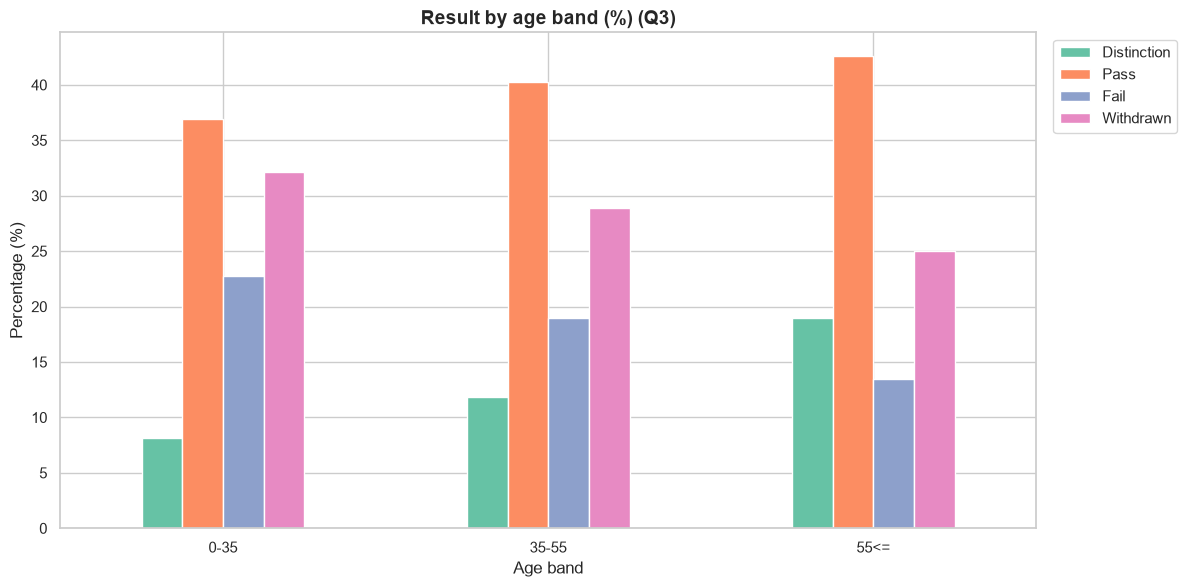

In [21]:
# A) Barras agrupadas: age_band × resultado (% por faixa etária).
ct = pd.crosstab(df_master["age_band"], df_master["resultado"]).reindex(AGE_ORDER)[RESULT_ORDER]
fig = viz.grouped_pct(ct, "Result by age band (%) (Q3)", "Age band", col_order=RESULT_ORDER)
viz.save_fig(fig, "p3_A_edad.png"); plt.show()

[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p3_B_genero.png


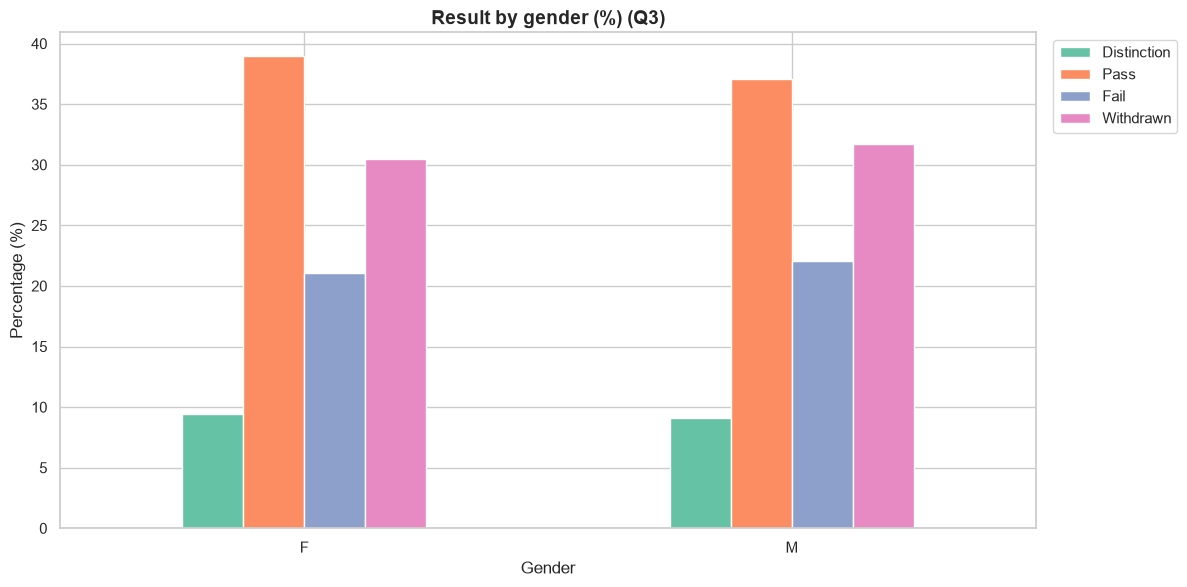

In [22]:
# B) Barras agrupadas: gênero × resultado.
ct = pd.crosstab(df_master["gender"], df_master["resultado"])[RESULT_ORDER]
fig = viz.grouped_pct(ct, "Result by gender (%) (Q3)", "Gender", col_order=RESULT_ORDER)
viz.save_fig(fig, "p3_B_genero.png"); plt.show()

[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p3_C_educacion.png


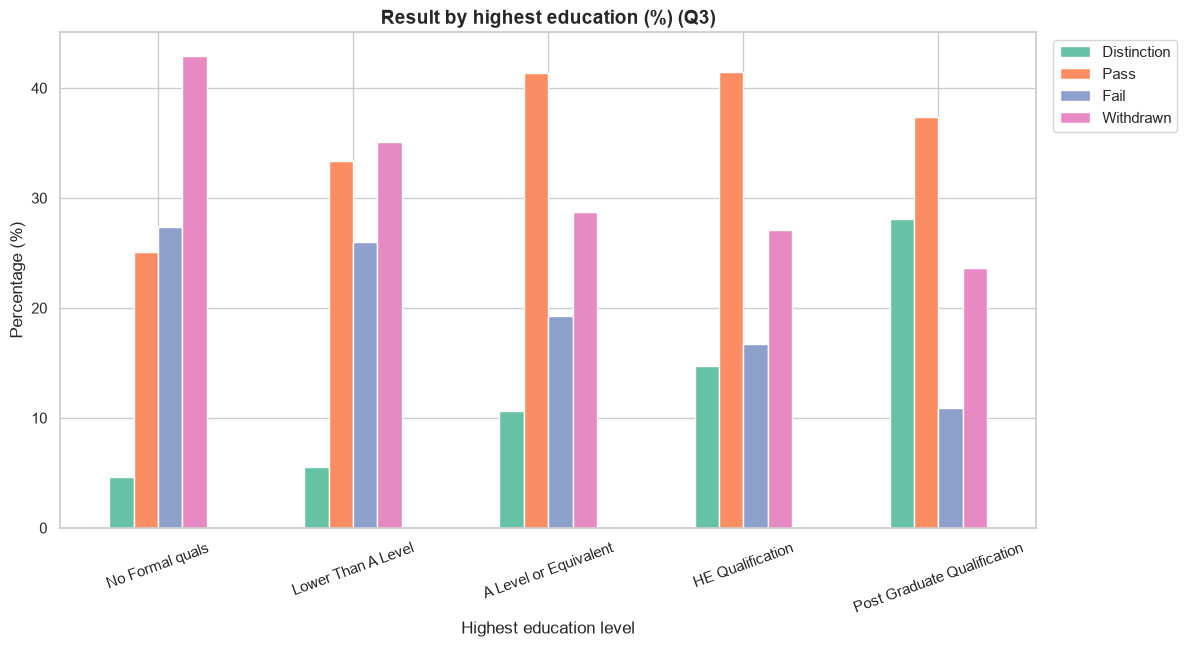

In [23]:
# C) Barras agrupadas: highest_education × resultado (ordenado por nível).
ct = pd.crosstab(df_master["highest_education"], df_master["resultado"]).reindex(EDUCATION_ORDER)[RESULT_ORDER]
fig = viz.grouped_pct(ct, "Result by highest education (%) (Q3)", "Highest education level", col_order=RESULT_ORDER)
fig.axes[0].tick_params(axis="x", labelrotation=20)
viz.save_fig(fig, "p3_C_educacion.png"); plt.show()

[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p3_D_discapacidad.png


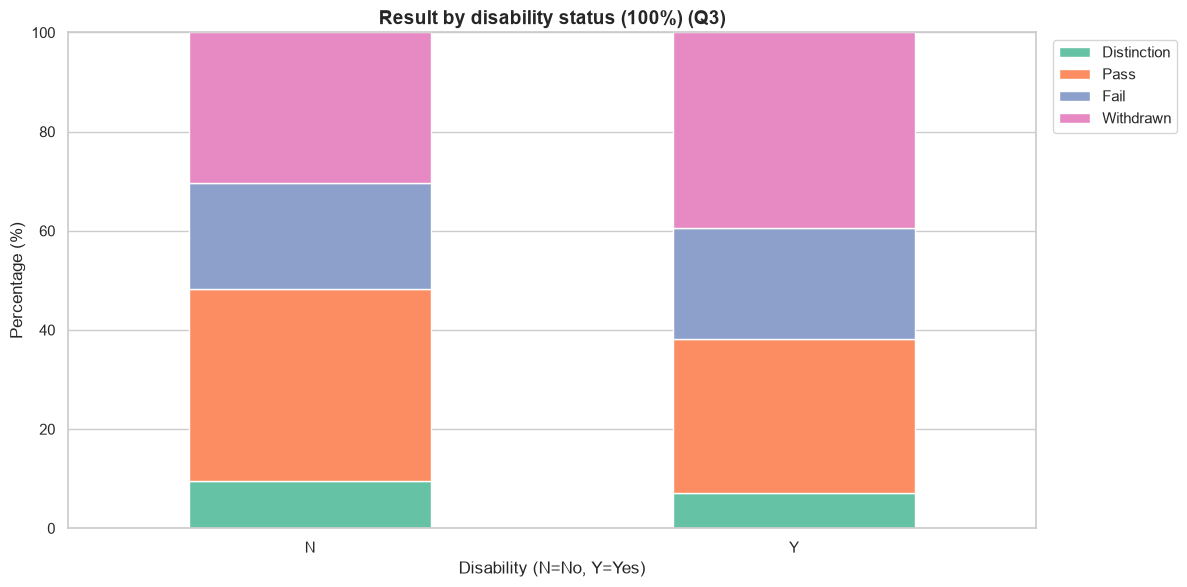

In [24]:
# D) Barras empilhadas: disability × resultado.
ct = pd.crosstab(df_master["disability"], df_master["resultado"])[RESULT_ORDER]
fig = viz.stacked_100(ct, "Result by disability status (100%) (Q3)",
                      "Disability (N=No, Y=Yes)", col_order=RESULT_ORDER)
viz.save_fig(fig, "p3_D_discapacidad.png"); plt.show()

[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p3_E_heatmap_correlacion.png


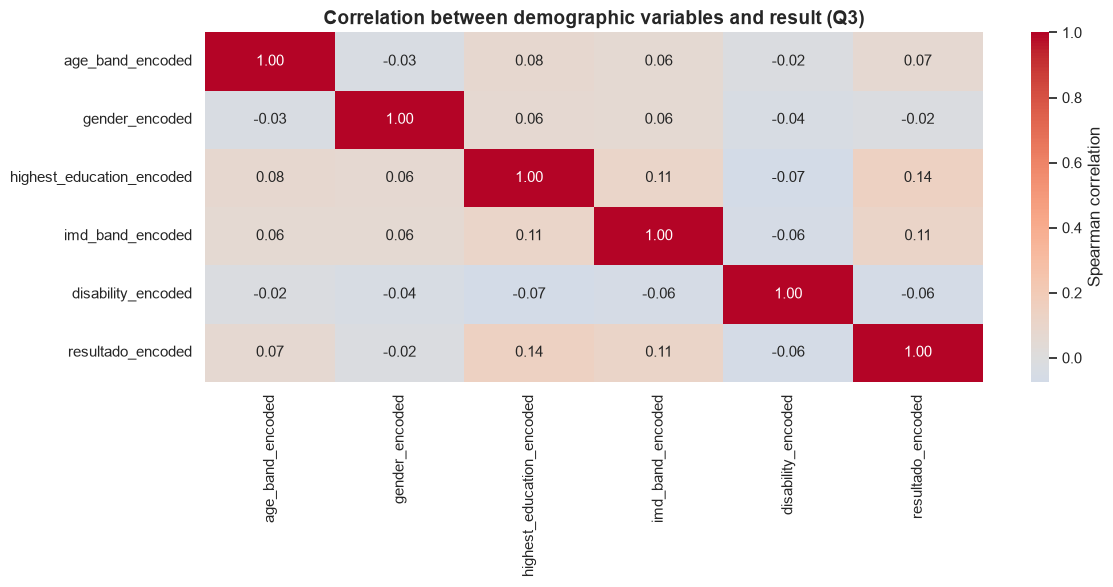

In [25]:
# E) Heatmap de correlação entre variáveis demográficas codificadas e resultado.
cols_enc = ["age_band_encoded", "gender_encoded", "highest_education_encoded",
            "imd_band_encoded", "disability_encoded", "resultado_encoded"]
corr = df_master[cols_enc].corr(method="spearman")
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"label": "Spearman correlation"})
ax.set_title("Correlation between demographic variables and result (Q3)")
fig.tight_layout(); viz.save_fig(fig, "p3_E_heatmap_correlacion.png"); plt.show()

In [26]:
# Odds Ratio: deficiência vs. taxa de desistência.
df_master["retirado_flag"] = (df_master["resultado"] == "Withdrawn").astype(int)
tab = pd.crosstab(df_master["disability"], df_master["retirado_flag"])
# tab: linhas N/Y, colunas 0/1
a = tab.loc["Y", 1]; b = tab.loc["Y", 0]   # deficiência: desistentes / não desistentes
c = tab.loc["N", 1]; d = tab.loc["N", 0]   # sem deficiência
odds_ratio = (a / b) / (c / d)
ret_Y = a / (a + b) * 100
ret_N = c / (c + d) * 100
print(f"Taxa de desistência com deficiência (Y): {ret_Y:.1f}%")
print(f"Taxa de desistência sem deficiência (N): {ret_N:.1f}%")
print(f"Odds Ratio de desistência (Y vs N): {odds_ratio:.2f}")
findings["p3_odds_ratio_discapacidad"] = round(float(odds_ratio), 2)
findings["p3_retiro_discapacidad"] = (round(float(ret_Y), 1), round(float(ret_N), 1))

# Grupo com maior/menor aprovação por variável.
def aprob_por_grupo(var, orden=None):
    ct = pd.crosstab(df_master[var], df_master["resultado"])
    if orden: ct = ct.reindex(orden)
    aprob = (ct[["Pass", "Distinction"]].sum(axis=1) / ct.sum(axis=1) * 100)
    return aprob.idxmax(), aprob.max(), aprob.idxmin(), aprob.min()

for v, orden in [("age_band", AGE_ORDER), ("gender", None),
                 ("highest_education", EDUCATION_ORDER), ("disability", None)]:
    gmax, vmax, gmin, vmin = aprob_por_grupo(v, orden)
    print(f"{v}: maior aprovação = {gmax} ({vmax:.1f}%), menor = {gmin} ({vmin:.1f}%)")

Taxa de desistência com deficiência (Y): 39.3%
Taxa de desistência sem deficiência (N): 30.3%
Odds Ratio de desistência (Y vs N): 1.49
age_band: maior aprovação = 55<= (61.6%), menor = 0-35 (45.0%)
gender: maior aprovação = F (48.4%), menor = M (46.2%)
highest_education: maior aprovação = Post Graduate Qualification (65.5%), menor = No Formal quals (29.7%)
disability: maior aprovação = N (48.2%), menor = Y (38.1%)


### 📌 Resumo dos achados — Pergunta 3

In [27]:
print("RESUMO Q3 — Perfil dos estudantes")
print("-" * 60)
for v in demograficas:
    p = chi2_resultados[v]["p"]
    print(f"- {v}: Qui² p={p:.2e} -> {'associação significativa com o resultado' if p<0.05 else 'sem associação clara'}.")
print(f"- Estudantes com deficiência desistem mais: {ret_Y:.1f}% vs {ret_N:.1f}% (OR={odds_ratio:.2f}).")
print("- A escolaridade prévia mostra a associação mais forte com o sucesso acadêmico.")

RESUMO Q3 — Perfil dos estudantes
------------------------------------------------------------
- age_band: Qui² p=2.83e-45 -> associação significativa com o resultado.
- gender: Qui² p=8.83e-04 -> associação significativa com o resultado.
- highest_education: Qui² p=9.18e-212 -> associação significativa com o resultado.
- disability: Qui² p=8.14e-30 -> associação significativa com o resultado.
- Estudantes com deficiência desistem mais: 39.3% vs 30.3% (OR=1.49).
- A escolaridade prévia mostra a associação mais forte com o sucesso acadêmico.


## 7. Pergunta 4 — Evasão do curso

**O quê:** entre os estudantes que desistiram (`resultado == 'Withdrawn'`),
analisamos **quando** ocorre a evasão usando `date_unregistration` (dia do curso,
onde 0 = início). Definimos janelas de evasão e comparamos `dias_hasta_retiro`
entre módulos.

**Por quê:** conhecer o momento da evasão permite posicionar intervenções (antes
do dia 30, antes do dia 90, etc.).

Visualizações: (A) histograma com linhas nos dias 30/90/180, (B) KDE,
(C) boxplot por módulo, (D) curva acumulada de evasão.

In [28]:
ret = df_master[df_master["resultado"] == "Withdrawn"].copy()
ret_valid = ret.dropna(subset=["date_unregistration"])
print(f"Estudantes desistentes: {len(ret):,} | com data de baixa: {len(ret_valid):,}")

mediana_retiro = ret_valid["date_unregistration"].median()
print(f"Mediana do dia de desistência: {mediana_retiro:.0f}")

# Janelas: % que desiste nos primeiros 30, 90, 180 dias (desde o início do curso).
for d in (30, 90, 180):
    pct = (ret_valid["date_unregistration"] <= d).mean() * 100
    print(f"% desistentes nos primeiros {d} dias: {pct:.1f}%")
    findings[f"p4_pct_{d}d"] = round(float(pct), 1)
findings["p4_mediana_dia_retiro"] = float(mediana_retiro)

Estudantes desistentes: 10,156 | com data de baixa: 10,063
Mediana do dia de desistência: 27
% desistentes nos primeiros 30 dias: 50.9%
% desistentes nos primeiros 90 dias: 69.8%
% desistentes nos primeiros 180 dias: 92.5%


[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p4_A_histograma_retiro.png


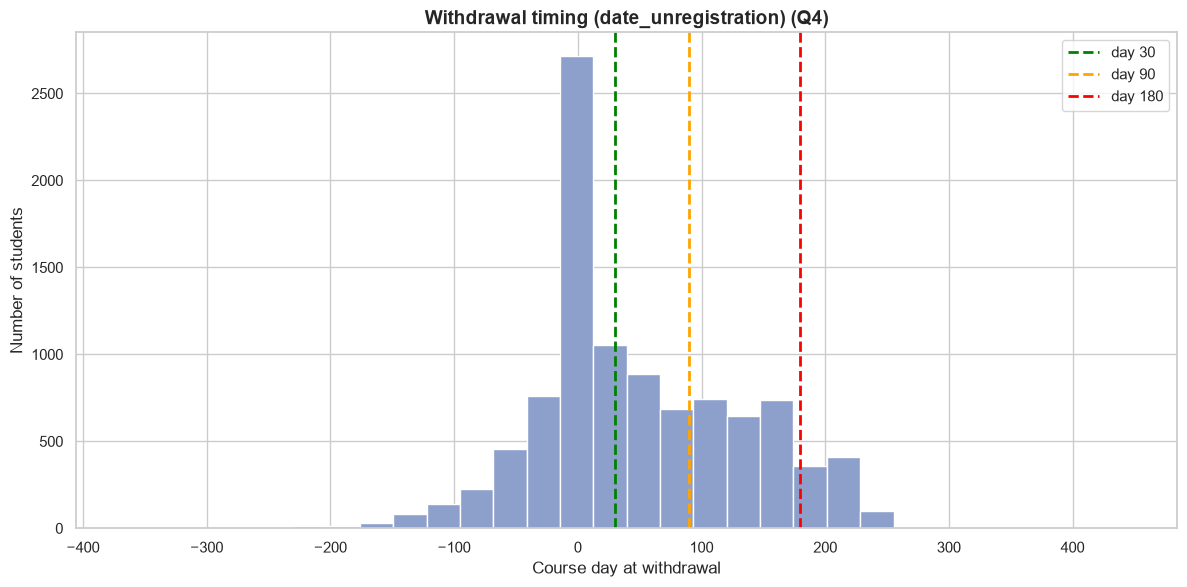

In [29]:
# A) Histograma de date_unregistration com linhas em 30, 90, 180.
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(ret_valid["date_unregistration"], bins=30, color=sns.color_palette("Set2")[2],
        edgecolor="white")
for d, c in [(30, "green"), (90, "orange"), (180, "red")]:
    ax.axvline(d, color=c, linestyle="--", linewidth=2, label=f"day {d}")
ax.set_title("Withdrawal timing (date_unregistration) (Q4)")
ax.set_xlabel("Course day at withdrawal"); ax.set_ylabel("Number of students")
ax.legend()
fig.tight_layout(); viz.save_fig(fig, "p4_A_histograma_retiro.png"); plt.show()

[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p4_B_kde_retiro.png


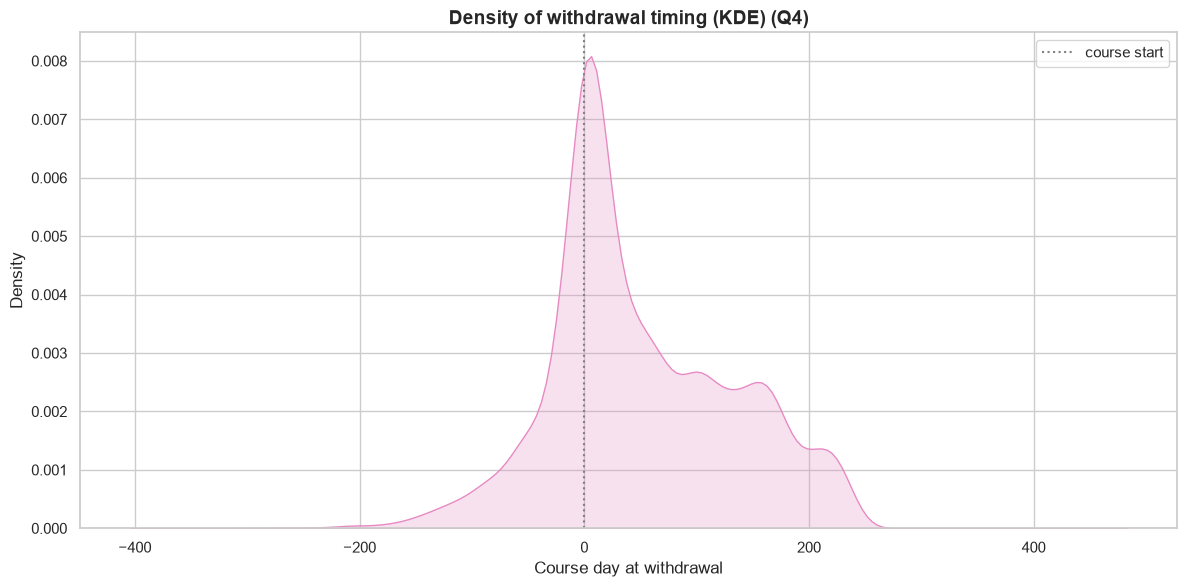

In [30]:
# B) KDE do momento de desistência.
fig, ax = plt.subplots(figsize=(12, 6))
sns.kdeplot(ret_valid["date_unregistration"], fill=True, color=sns.color_palette("Set2")[3], ax=ax)
ax.axvline(0, color="grey", linestyle=":", linewidth=1.5, label="course start")
ax.set_title("Density of withdrawal timing (KDE) (Q4)")
ax.set_xlabel("Course day at withdrawal"); ax.set_ylabel("Density")
ax.legend()
fig.tight_layout(); viz.save_fig(fig, "p4_B_kde_retiro.png"); plt.show()

C:\Users\KELLY\AppData\Local\Temp\ipykernel_29068\2041372777.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ret_dias, x="code_module", y="dias_hasta_retiro",


[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p4_C_boxplot_dias_modulo.png


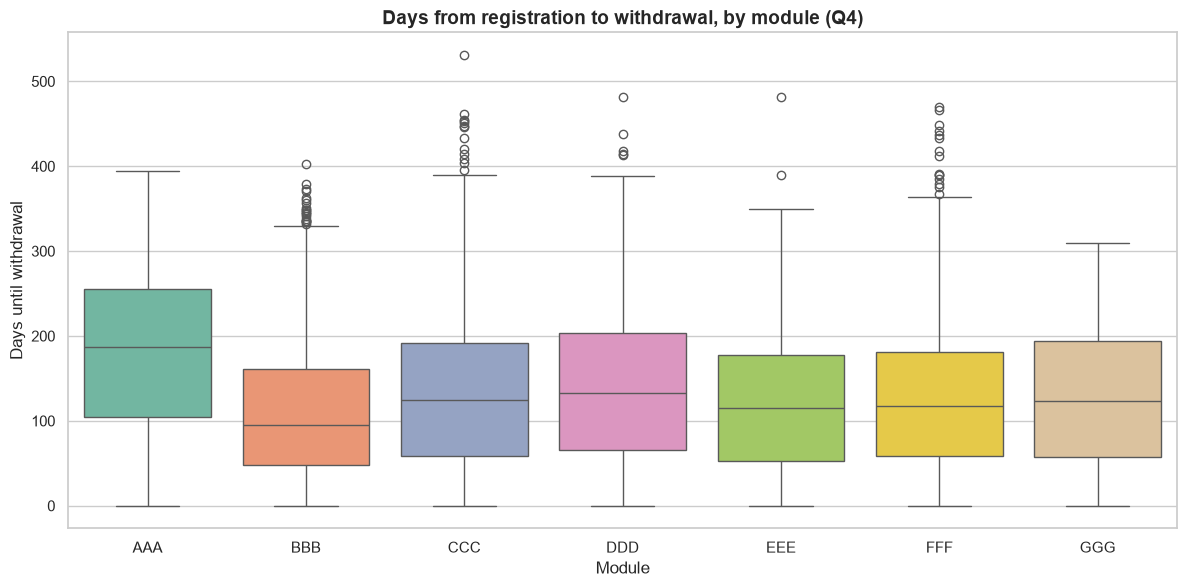

In [31]:
# C) Boxplot de dias_hasta_retiro por módulo.
ret_dias = ret.dropna(subset=["dias_hasta_retiro"])
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=ret_dias, x="code_module", y="dias_hasta_retiro",
            order=sorted(ret_dias["code_module"].unique()), palette="Set2", ax=ax)
ax.set_title("Days from registration to withdrawal, by module (Q4)")
ax.set_xlabel("Module"); ax.set_ylabel("Days until withdrawal")
fig.tight_layout(); viz.save_fig(fig, "p4_C_boxplot_dias_modulo.png"); plt.show()

[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p4_D_curva_abandono.png


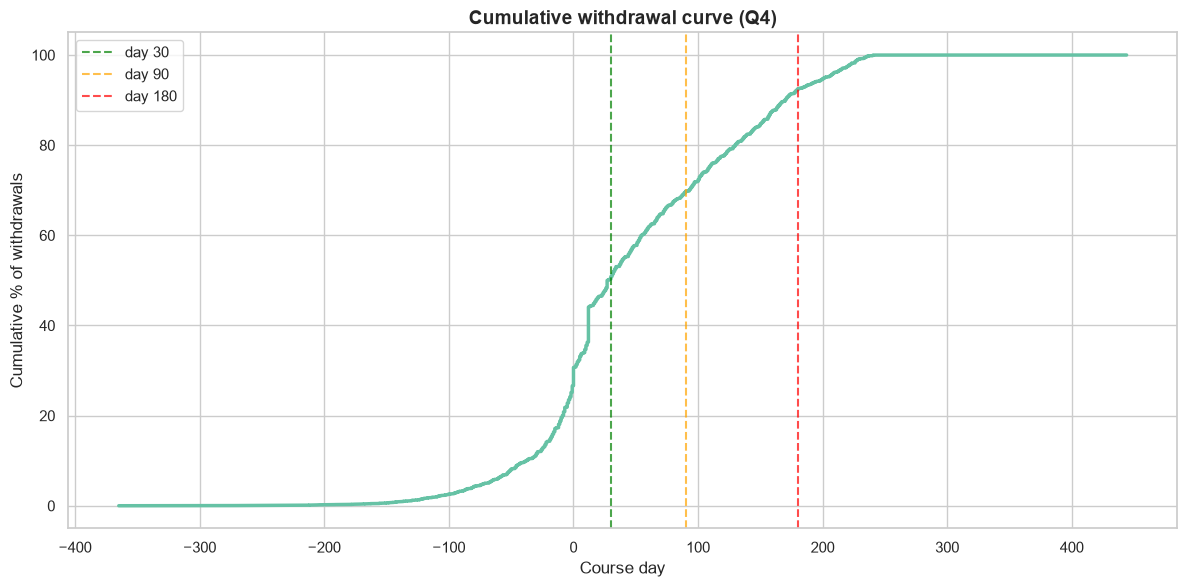

In [32]:
# D) Curva acumulada de evasão (por dia do curso).
orden = np.sort(ret_valid["date_unregistration"].values)
acum = np.arange(1, len(orden) + 1) / len(orden) * 100
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(orden, acum, color=sns.color_palette("Set2")[0], linewidth=2.5)
for d, c in [(30, "green"), (90, "orange"), (180, "red")]:
    ax.axvline(d, color=c, linestyle="--", alpha=0.7, label=f"day {d}")
ax.set_title("Cumulative withdrawal curve (Q4)")
ax.set_xlabel("Course day"); ax.set_ylabel("Cumulative % of withdrawals")
ax.legend()
fig.tight_layout(); viz.save_fig(fig, "p4_D_curva_abandono.png"); plt.show()

In [33]:
# Módulo com maior taxa de evasão precoce (desistência em <=30 dias, sobre o total de matriculados).
total_por_mod = df_master.groupby("code_module", observed=True).size()
temprano = ret_valid[ret_valid["date_unregistration"] <= 30].groupby("code_module", observed=True).size()
tasa_temprana = (temprano / total_por_mod * 100).sort_values(ascending=False)
print("Taxa de evasão precoce (desistência <=30 dias) por módulo (%):")
print(tasa_temprana.round(2).to_string())
findings["p4_modulo_abandono_temprano"] = (tasa_temprana.idxmax(), round(float(tasa_temprana.max()), 2))

Taxa de evasão precoce (desistência <=30 dias) por módulo (%):
code_module
CCC    21.00
BBB    18.81
DDD    16.04
FFF    15.23
EEE    13.02
AAA     4.14
GGG     3.91


### 📌 Resumo dos achados — Pergunta 4

In [34]:
print("RESUMO Q4 — Evasão do curso")
print("-" * 60)
print(f"- Mediana do dia de desistência: {mediana_retiro:.0f}.")
print(f"- {findings['p4_pct_30d']:.1f}% desiste antes do dia 30; "
      f"{findings['p4_pct_90d']:.1f}% antes do dia 90; {findings['p4_pct_180d']:.1f}% antes do dia 180.")
print(f"- Módulo com maior evasão precoce: {tasa_temprana.idxmax()} ({tasa_temprana.max():.1f}%).")
print("- Boa parte das desistências ocorre no início (inclusive antes do dia 0), indicando evasão muito precoce.")

RESUMO Q4 — Evasão do curso
------------------------------------------------------------
- Mediana do dia de desistência: 27.
- 50.9% desiste antes do dia 30; 69.8% antes do dia 90; 92.5% antes do dia 180.
- Módulo com maior evasão precoce: CCC (21.0%).
- Boa parte das desistências ocorre no início (inclusive antes do dia 0), indicando evasão muito precoce.


## 8. Pergunta 5 — Comparação entre módulos

**O quê:** para cada módulo calculamos as taxas de aprovação, desistência,
distinção e reprovação, além da média de score e dos cliques médios. Geramos
rankings.

**Por quê:** comparar módulos identifica boas práticas (cursos bem-sucedidos) e
cursos que precisam de redesenho.

Visualizações: (A) barras horizontais de aprovação, (B) empilhadas 100%,
(C) lollipop de desistência, (D) heatmap módulo × métrica, (E) dispersão
aprovação vs cliques com tamanho = nº de estudantes.

In [35]:
from src.preprocess import RESULT_ORDER

ct = pd.crosstab(df_master["code_module"], df_master["resultado"])[RESULT_ORDER]
pct = ct.div(ct.sum(axis=1), axis=0) * 100
metricas = pd.DataFrame({
    "tasa_aprobacion": pct["Pass"] + pct["Distinction"],
    "tasa_retiro": pct["Withdrawn"],
    "tasa_distincion": pct["Distinction"],
    "tasa_reprobacion": pct["Fail"],
    "n_estudiantes": ct.sum(axis=1),
})
metricas["score_promedio"] = df_master.groupby("code_module", observed=True)["score_promedio"].mean()
metricas["clicks_promedio"] = df_master.groupby("code_module", observed=True)["clicks_totales"].mean()
metricas = metricas.round(2)
print("Métricas por módulo:")
print(metricas.to_string())

findings["p5_metricas"] = metricas.round(1).to_dict("index")
findings["p5_top_aprobacion"] = metricas["tasa_aprobacion"].idxmax()
findings["p5_top_retiro"] = metricas["tasa_retiro"].idxmax()

Métricas por módulo:
             tasa_aprobacion  tasa_retiro  tasa_distincion  tasa_reprobacion  n_estudiantes  score_promedio  clicks_promedio
code_module                                                                                                                 
AAA                    70.99        16.84             5.88             12.17            748           68.26          1666.65
BBB                    47.46        30.19             8.56             22.34           7909           73.33           661.80
CCC                    37.84        44.54            11.23             17.61           4434           67.13          1055.97
DDD                    41.61        35.87             6.11             22.51           6272           67.42           881.71
EEE                    56.24        24.61            12.13             19.15           2934           80.05          1357.95
FFF                    47.00        30.96             8.63             22.04           7762           75

[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p5_A_aprobacion_modulo.png


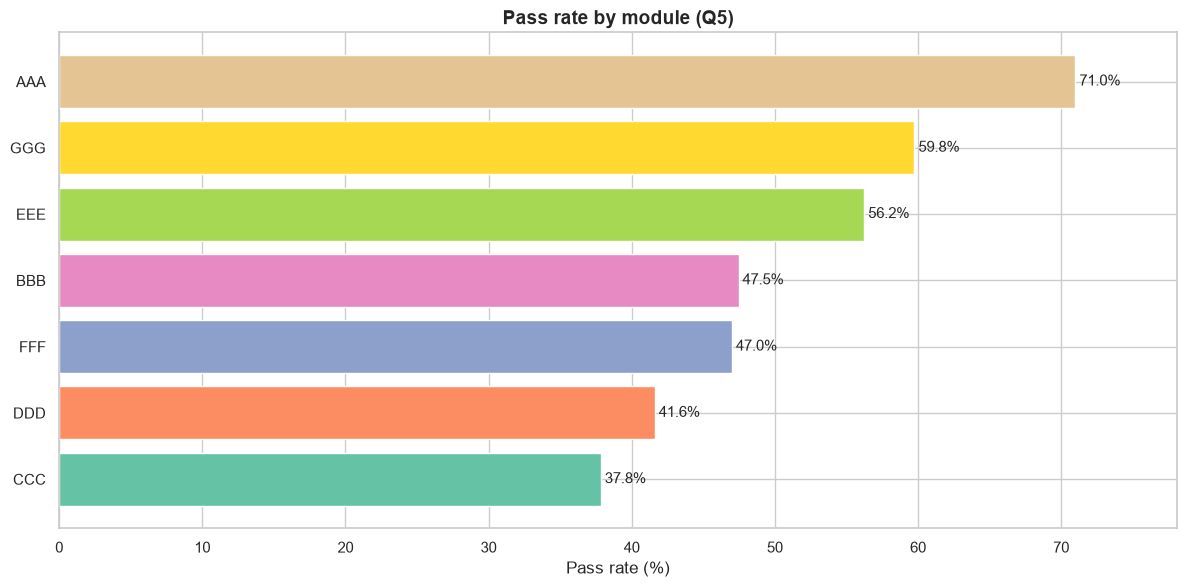

In [36]:
# A) Barras horizontais: taxa de aprovação por módulo (desc).
ord_aprob = metricas["tasa_aprobacion"].sort_values()
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(ord_aprob.index, ord_aprob.values, color=sns.color_palette("Set2", len(ord_aprob)))
for i, v in enumerate(ord_aprob.values):
    ax.text(v, i, f" {v:.1f}%", va="center")
ax.set_title("Pass rate by module (Q5)")
ax.set_xlabel("Pass rate (%)"); ax.margins(x=0.1)
fig.tight_layout(); viz.save_fig(fig, "p5_A_aprobacion_modulo.png"); plt.show()

[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p5_B_apiladas_modulo.png


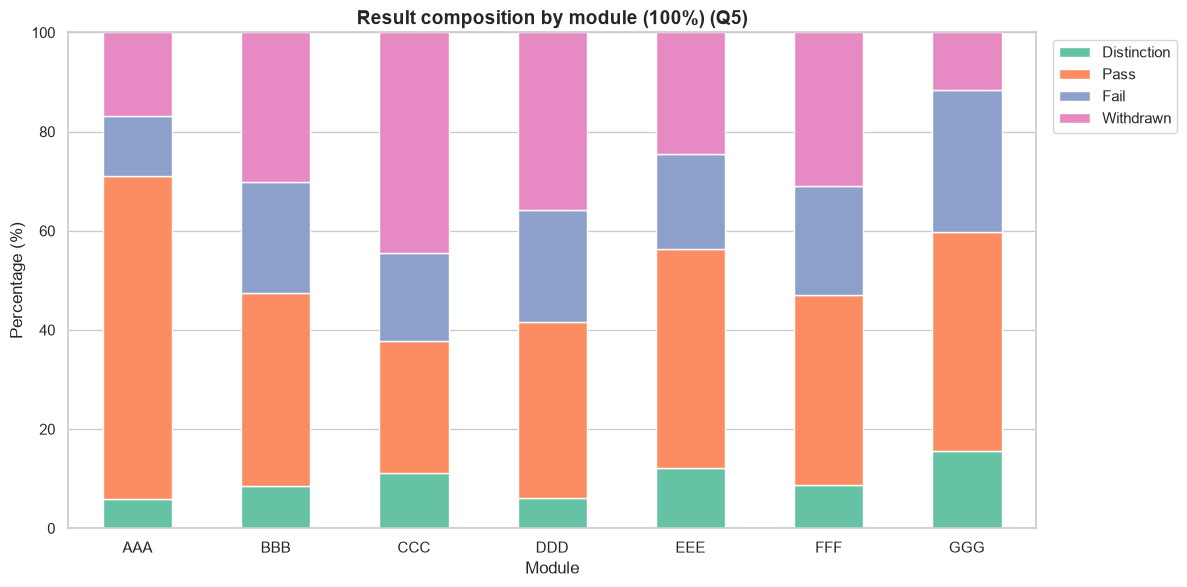

In [37]:
# B) Barras empilhadas 100% por módulo.
fig = viz.stacked_100(ct, "Result composition by module (100%) (Q5)",
                      "Module", col_order=RESULT_ORDER)
viz.save_fig(fig, "p5_B_apiladas_modulo.png"); plt.show()

[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p5_C_lollipop_retiro.png


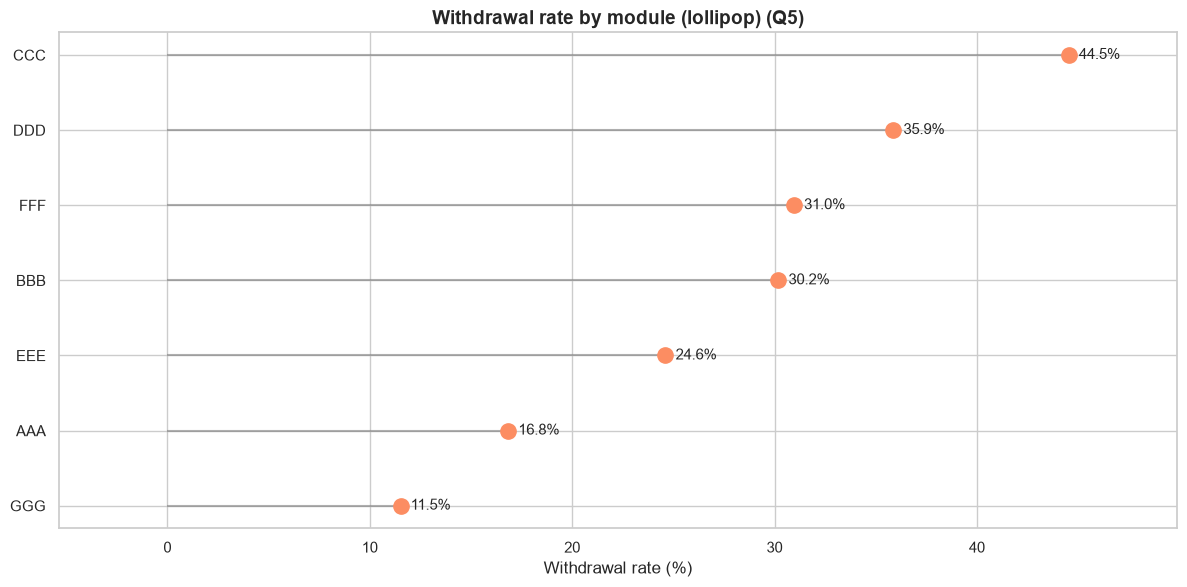

In [38]:
# C) Lollipop chart: taxa de desistência por módulo.
ord_ret = metricas["tasa_retiro"].sort_values()
fig, ax = plt.subplots(figsize=(12, 6))
ax.hlines(y=ord_ret.index, xmin=0, xmax=ord_ret.values, color="grey", alpha=0.6)
ax.plot(ord_ret.values, ord_ret.index, "o", markersize=11, color=sns.color_palette("Set2")[1])
for y, v in zip(ord_ret.index, ord_ret.values):
    ax.text(v + 0.5, y, f"{v:.1f}%", va="center")
ax.set_title("Withdrawal rate by module (lollipop) (Q5)")
ax.set_xlabel("Withdrawal rate (%)"); ax.margins(x=0.12)
fig.tight_layout(); viz.save_fig(fig, "p5_C_lollipop_retiro.png"); plt.show()

[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p5_D_heatmap_metricas.png


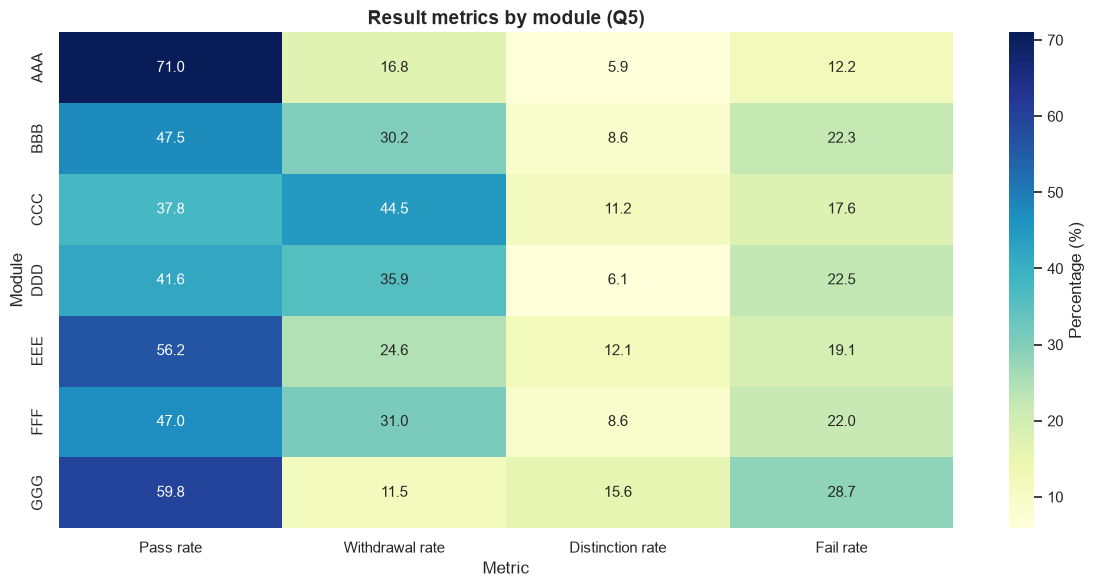

In [39]:
# D) Heatmap módulo × métrica.
cols = ["tasa_aprobacion", "tasa_retiro", "tasa_distincion", "tasa_reprobacion"]
labels = ["Pass rate", "Withdrawal rate", "Distinction rate", "Fail rate"]
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(metricas[cols].rename(columns=dict(zip(cols, labels))),
            annot=True, fmt=".1f", cmap="YlGnBu", ax=ax,
            cbar_kws={"label": "Percentage (%)"})
ax.set_title("Result metrics by module (Q5)")
ax.set_xlabel("Metric"); ax.set_ylabel("Module")
fig.tight_layout(); viz.save_fig(fig, "p5_D_heatmap_metricas.png"); plt.show()

[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p5_E_scatter_modulos.png


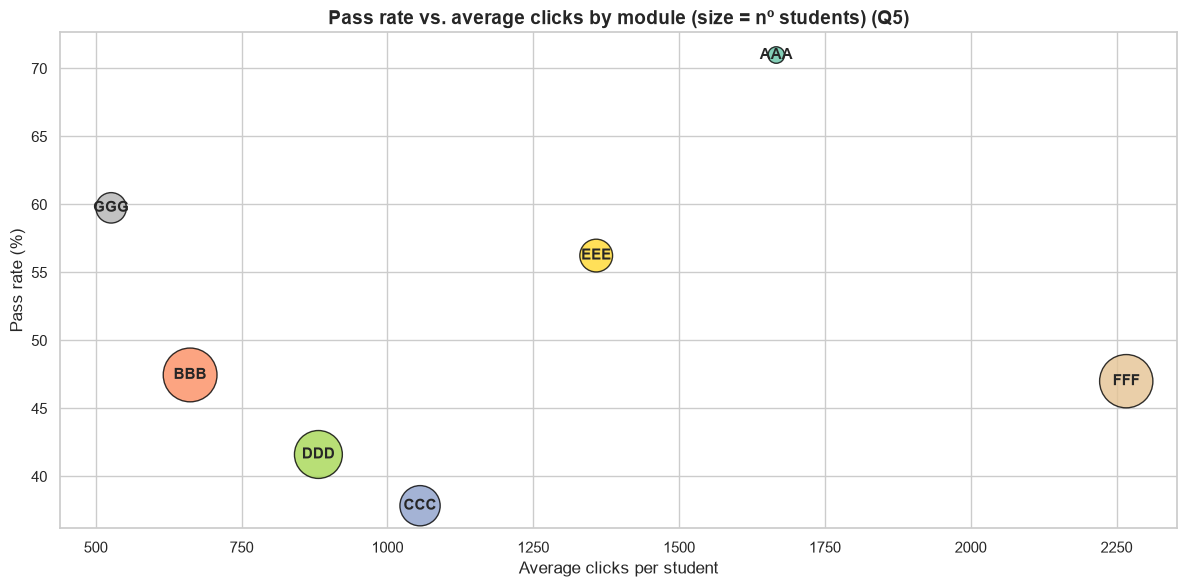

In [40]:
# E) Dispersão: tasa_aprobacion vs clicks_promedio, tamanho = nº estudantes.
fig, ax = plt.subplots(figsize=(12, 6))
sizes = metricas["n_estudiantes"] / metricas["n_estudiantes"].max() * 1500
ax.scatter(metricas["clicks_promedio"], metricas["tasa_aprobacion"], s=sizes,
           c=range(len(metricas)), cmap="Set2", alpha=0.8, edgecolor="black")
for mod, row in metricas.iterrows():
    ax.annotate(mod, (row["clicks_promedio"], row["tasa_aprobacion"]),
                ha="center", va="center", fontweight="bold")
ax.set_title("Pass rate vs. average clicks by module (size = nº students) (Q5)")
ax.set_xlabel("Average clicks per student"); ax.set_ylabel("Pass rate (%)")
fig.tight_layout(); viz.save_fig(fig, "p5_E_scatter_modulos.png"); plt.show()

### 📌 Resumo dos achados — Pergunta 5

In [41]:
print("RESUMO Q5 — Comparação entre módulos")
print("-" * 60)
print(f"- Maior aprovação: {metricas['tasa_aprobacion'].idxmax()} ({metricas['tasa_aprobacion'].max():.1f}%).")
print(f"- Menor aprovação: {metricas['tasa_aprobacion'].idxmin()} ({metricas['tasa_aprobacion'].min():.1f}%).")
print(f"- Maior desistência: {metricas['tasa_retiro'].idxmax()} ({metricas['tasa_retiro'].max():.1f}%).")
print(f"- Maior taxa de distinção: {metricas['tasa_distincion'].idxmax()} ({metricas['tasa_distincion'].max():.1f}%).")
print("- Há relação positiva entre cliques médios e taxa de aprovação no nível de módulo.")

RESUMO Q5 — Comparação entre módulos
------------------------------------------------------------
- Maior aprovação: AAA (71.0%).
- Menor aprovação: CCC (37.8%).
- Maior desistência: CCC (44.5%).
- Maior taxa de distinção: GGG (15.6%).
- Há relação positiva entre cliques médios e taxa de aprovação no nível de módulo.


## 9. Bônus 6 — Análise das avaliações (assessments)

**O quê:** estudamos a distribuição de scores por tipo de avaliação (TMA, CMA,
Exam), a evolução da média de score conforme a data de entrega, e se entregar
**atrasado** se associa a notas piores.

**Por quê:** entender o comportamento nas avaliações complementa a visão do
desempenho e detecta o efeito da procrastinação.

C:\Users\KELLY\AppData\Local\Temp\ipykernel_29068\4071525556.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sa_valid, x="assessment_type", y="score",


[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p6_A_scores_por_tipo.png


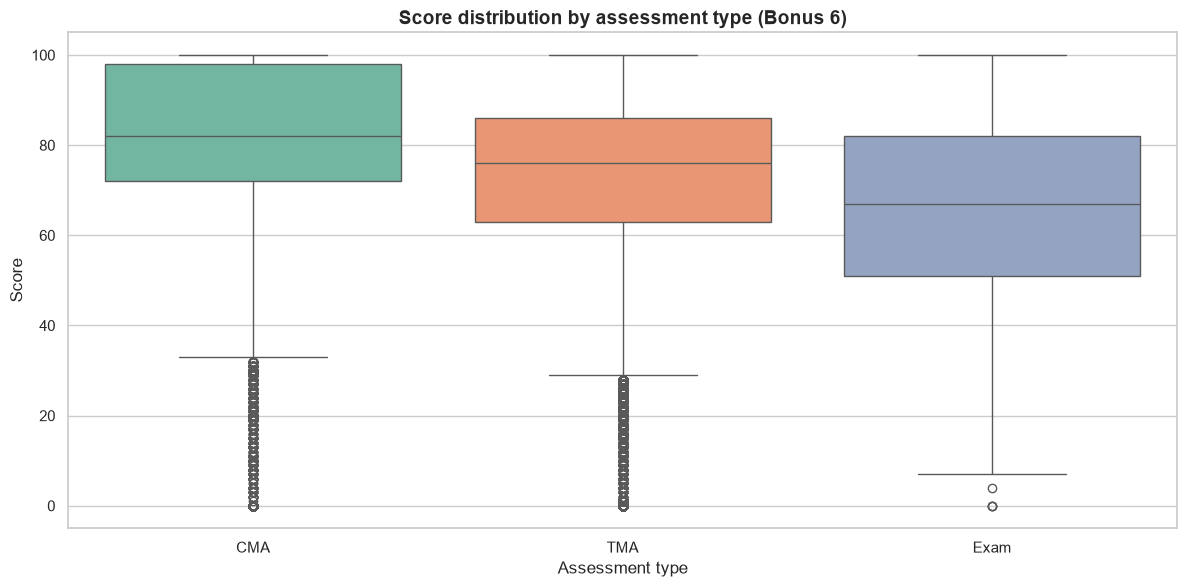

                   count  mean   std  min   25%   50%   75%    max
assessment_type                                                   
CMA              69956.0  81.0  17.8  0.0  72.0  82.0  98.0  100.0
Exam              4959.0  65.6  20.6  0.0  51.0  67.0  82.0  100.0
TMA              96916.0  72.6  18.5  0.0  63.0  76.0  86.0  100.0


In [42]:
# Unimos studentAssessment com metadados de assessments.
sa = assessment.merge(
    data["assessments"][["id_assessment", "assessment_type", "date", "code_module"]],
    on="id_assessment", how="left")
sa_valid = sa[~sa["no_submitted"]].copy()

# Distribuição de scores por tipo de avaliação.
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=sa_valid, x="assessment_type", y="score",
            order=["CMA", "TMA", "Exam"], palette="Set2", ax=ax)
ax.set_title("Score distribution by assessment type (Bonus 6)")
ax.set_xlabel("Assessment type"); ax.set_ylabel("Score")
fig.tight_layout(); viz.save_fig(fig, "p6_A_scores_por_tipo.png"); plt.show()

print(sa_valid.groupby("assessment_type", observed=True)["score"].describe().round(1).to_string())

[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p6_B_evolucion_score.png


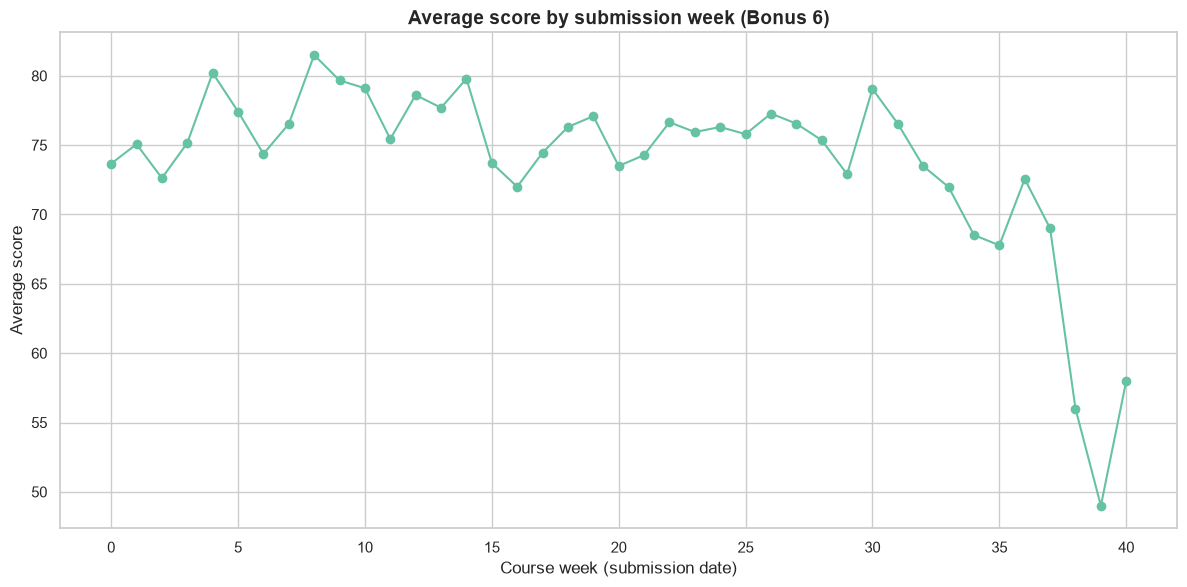

In [43]:
# Evolução da média de score ao longo do tempo (data de entrega).
sa_time = sa_valid.dropna(subset=["date_submitted"]).copy()
sa_time["semana"] = (sa_time["date_submitted"] // 7).astype(int)
evol = sa_time.groupby("semana", observed=True)["score"].mean()
evol = evol[(evol.index >= 0) & (evol.index <= 40)]
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(evol.index, evol.values, marker="o", color=sns.color_palette("Set2")[0])
ax.set_title("Average score by submission week (Bonus 6)")
ax.set_xlabel("Course week (submission date)"); ax.set_ylabel("Average score")
fig.tight_layout(); viz.save_fig(fig, "p6_B_evolucion_score.png"); plt.show()

Score por pontualidade da entrega:
                 mean  median   count
entrega_tardia                       
Late            75.02    80.0   49184
On time         76.35    80.0  119782


C:\Users\KELLY\AppData\Local\Temp\ipykernel_29068\2477522440.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sa_late, x="entrega_tardia", y="score",


[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p6_C_entrega_tardia.png


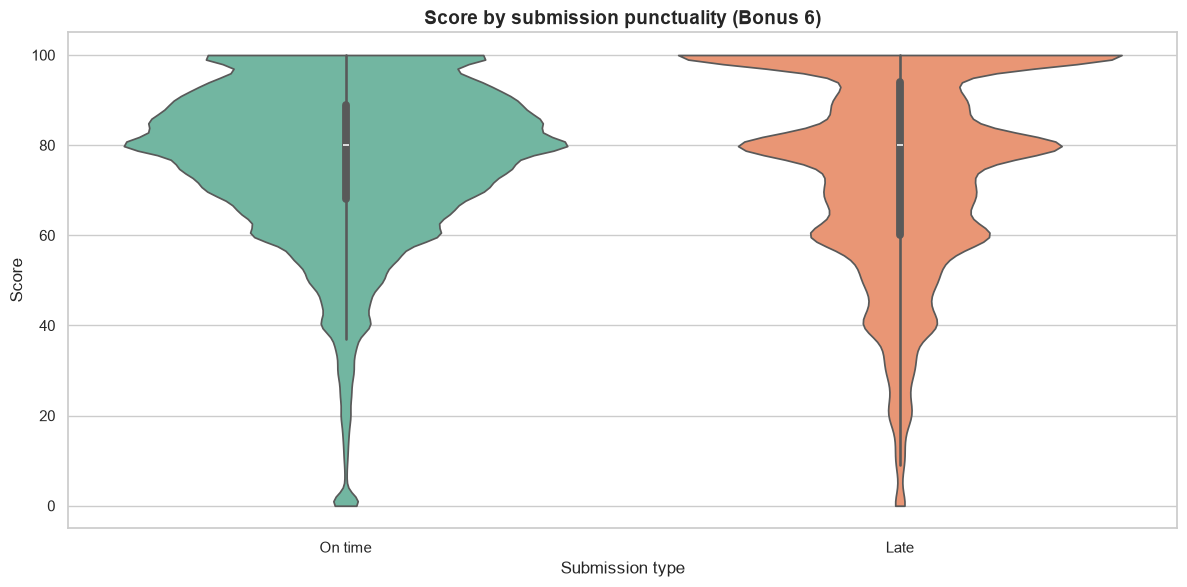


Mann-Whitney (no prazo > atrasada): U=2940315131, p=7.222e-01


In [44]:
# Entregar atrasado -> notas piores? Comparamos entregas no prazo vs atrasadas.
sa_late = sa_valid.dropna(subset=["date_submitted", "date"]).copy()
sa_late["dias_retraso"] = sa_late["date_submitted"] - sa_late["date"]
sa_late["entrega_tardia"] = np.where(sa_late["dias_retraso"] > 0, "Late", "On time")
comp = sa_late.groupby("entrega_tardia", observed=True)["score"].agg(["mean", "median", "count"]).round(2)
print("Score por pontualidade da entrega:")
print(comp.to_string())

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=sa_late, x="entrega_tardia", y="score",
               order=["On time", "Late"], palette="Set2", cut=0, ax=ax)
ax.set_title("Score by submission punctuality (Bonus 6)")
ax.set_xlabel("Submission type"); ax.set_ylabel("Score")
fig.tight_layout(); viz.save_fig(fig, "p6_C_entrega_tardia.png"); plt.show()

# Teste de Mann-Whitney.
a = sa_late.loc[sa_late["entrega_tardia"] == "On time", "score"]
b = sa_late.loc[sa_late["entrega_tardia"] == "Late", "score"]
U, p_mw = stats.mannwhitneyu(a, b, alternative="greater")
print(f"\nMann-Whitney (no prazo > atrasada): U={U:.0f}, p={p_mw:.3e}")
findings["p6_score_a_tiempo"] = float(comp.loc["On time", "mean"])
findings["p6_score_tardia"] = float(comp.loc["Late", "mean"]) if "Late" in comp.index else None
findings["p6_mannwhitney_p"] = float(p_mw)

### 📌 Resumo dos achados — Bônus 6

In [45]:
print("RESUMO Bônus 6 — Avaliações")
print("-" * 60)
med = sa_valid.groupby("assessment_type", observed=True)["score"].mean().round(1)
for t in ["CMA", "TMA", "Exam"]:
    if t in med.index:
        print(f"- Score médio {t}: {med[t]:.1f}.")
if findings["p6_score_tardia"] is not None:
    print(f"- Entregas no prazo ({findings['p6_score_a_tiempo']:.1f}) vs atrasadas "
          f"({findings['p6_score_tardia']:.1f}); Mann-Whitney p={p_mw:.2e}.")
print("- A relação entre pontualidade e nota é fraca/não conclusiva com estes dados.")

RESUMO Bônus 6 — Avaliações
------------------------------------------------------------
- Score médio CMA: 81.0.
- Score médio TMA: 72.6.
- Score médio Exam: 65.6.
- Entregas no prazo (76.3) vs atrasadas (75.0); Mann-Whitney p=7.22e-01.
- A relação entre pontualidade e nota é fraca/não conclusiva com estes dados.


## 10. Bônus 7 — Segmentação dos estudantes (K-Means)

**O quê:** segmentamos os estudantes com **K-Means** usando: `clicks_totales`,
`score_promedio`, `dias_activos`, `highest_education_encoded` e
`imd_band_encoded`. Escalamos com `StandardScaler`, escolhemos K com o método do
cotovelo (2–10) e visualizamos em 2D com **PCA**.

**Por quê:** descobrir perfis latentes de estudantes permite desenhar
intervenções diferenciadas. Usamos `random_state=42` em tudo.

[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p7_A_metodo_codo.png


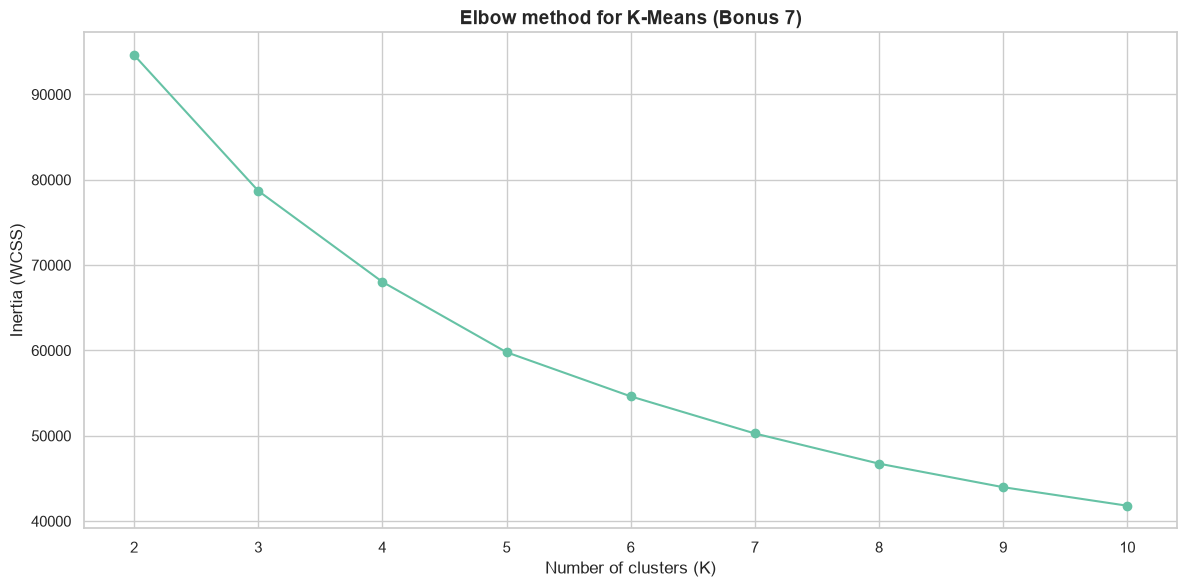

Inércias: {2: 94618, 3: 78707, 4: 68039, 5: 59793, 6: 54622, 7: 50274, 8: 46738, 9: 43980, 10: 41807}


In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

features = ["clicks_totales", "score_promedio", "dias_activos",
            "highest_education_encoded", "imd_band_encoded"]
df_clust = df_master.dropna(subset=["score_promedio"]).copy()
X = df_clust[features].fillna(df_clust[features].median())

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# Método do cotovelo (inércia) para K = 2..10.
inercias = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(Xs)
    inercias[k] = km.inertia_

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(list(inercias.keys()), list(inercias.values()), marker="o",
        color=sns.color_palette("Set2")[0])
ax.set_title("Elbow method for K-Means (Bonus 7)")
ax.set_xlabel("Number of clusters (K)"); ax.set_ylabel("Inertia (WCSS)")
fig.tight_layout(); viz.save_fig(fig, "p7_A_metodo_codo.png"); plt.show()
print("Inércias:", {k: round(v) for k, v in inercias.items()})

Variância explicada pelo PCA: [0.411 0.217] (total 62.9%)


[figura guardada] C:\Users\KELLY\Downloads\OULAD\oulad-analysis\outputs\figures\p7_B_pca_clusters.png


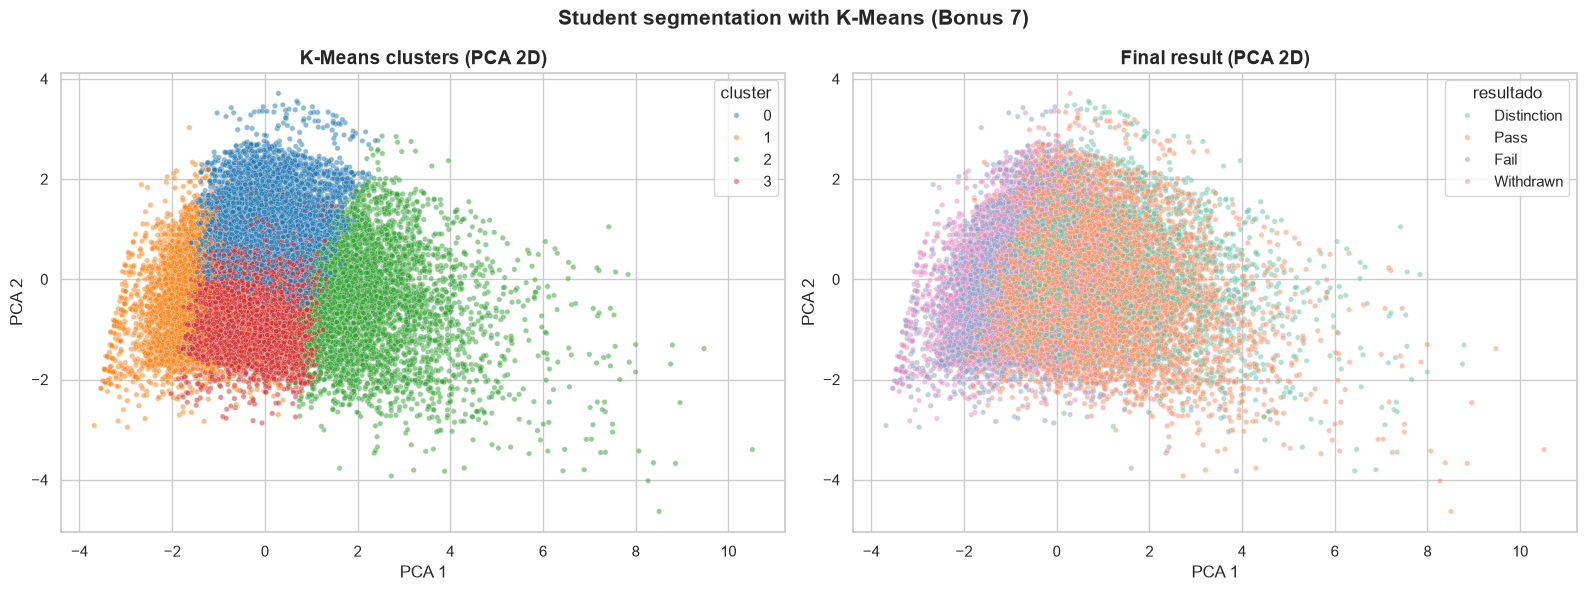

In [47]:
# K ótimo = 4 (equilíbrio razoável observado no cotovelo).
K_OPT = 4
km = KMeans(n_clusters=K_OPT, random_state=42, n_init=10)
df_clust["cluster"] = km.fit_predict(Xs)

# PCA 2D para visualização.
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(Xs)
df_clust["pca1"], df_clust["pca2"] = coords[:, 0], coords[:, 1]
print(f"Variância explicada pelo PCA: {pca.explained_variance_ratio_.round(3)} "
      f"(total {pca.explained_variance_ratio_.sum():.1%})")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=df_clust, x="pca1", y="pca2", hue="cluster", palette="tab10",
                alpha=0.5, s=15, ax=axes[0])
axes[0].set_title("K-Means clusters (PCA 2D)")
sns.scatterplot(data=df_clust, x="pca1", y="pca2", hue="resultado",
                hue_order=RESULT_ORDER, palette="Set2", alpha=0.5, s=15, ax=axes[1])
axes[1].set_title("Final result (PCA 2D)")
for a in axes:
    a.set_xlabel("PCA 1"); a.set_ylabel("PCA 2")
fig.suptitle("Student segmentation with K-Means (Bonus 7)", fontsize=15, fontweight="bold")
fig.tight_layout(); viz.save_fig(fig, "p7_B_pca_clusters.png"); plt.show()

In [48]:
# Perfil de cada cluster.
perfil = df_clust.groupby("cluster").agg(
    n=("id_student", "size"),
    clicks_medios=("clicks_totales", "mean"),
    score_medio=("score_promedio", "mean"),
    dias_activos_medios=("dias_activos", "mean"),
    educacion_media=("highest_education_encoded", "mean"),
    imd_media=("imd_band_encoded", "mean"),
).round(1)
# Distribuição de resultado por cluster (% por cluster).
res_clust = pd.crosstab(df_clust["cluster"], df_clust["resultado"], normalize="index").round(3) * 100
res_clust.columns = res_clust.columns.astype(str)  # evita CategoricalIndex no join
perfil = perfil.join(res_clust)
print("Perfil de cada cluster:")
print(perfil.to_string())
findings["p7_k_opt"] = K_OPT
findings["p7_pca_var"] = round(float(pca.explained_variance_ratio_.sum()), 3)
findings["p7_perfil"] = perfil.round(1).reset_index().to_dict("records")

Perfil de cada cluster:
            n  clicks_medios  score_medio  dias_activos_medios  educacion_media  imd_media  Distinction  Pass  Fail  Withdrawn
cluster                                                                                                                       
0        7781         1086.0         77.4                 59.8              2.0        7.1         12.5  53.7  18.0       15.8
1        4307          521.2         45.5                 32.5              1.6        3.6          0.2  17.9  45.0       37.0
2        4293         4534.5         82.0                159.2              1.9        4.4         27.7  66.3   4.7        1.4
3        9176          989.3         77.2                 54.2              1.6        2.1          9.3  49.7  22.7       18.4


### 📌 Resumo dos achados — Bônus 7

In [49]:
print("RESUMO Bônus 7 — Segmentação K-Means")
print("-" * 60)
print(f"- K ótimo escolhido: {K_OPT} clusters.")
print(f"- PCA 2D explica {pca.explained_variance_ratio_.sum():.1%} da variância.")
mejor = perfil["score_medio"].idxmax(); peor = perfil["score_medio"].idxmin()
print(f"- Cluster de maior desempenho: #{mejor} (score médio {perfil.loc[mejor,'score_medio']:.1f}, "
      f"{perfil.loc[mejor,'clicks_medios']:.0f} cliques).")
print(f"- Cluster de menor desempenho: #{peor} (score médio {perfil.loc[peor,'score_medio']:.1f}, "
      f"{perfil.loc[peor,'clicks_medios']:.0f} cliques).")
print("- Os clusters separam claramente perfis de alta vs baixa atividade/desempenho.")

RESUMO Bônus 7 — Segmentação K-Means
------------------------------------------------------------
- K ótimo escolhido: 4 clusters.
- PCA 2D explica 62.9% da variância.
- Cluster de maior desempenho: #2 (score médio 82.0, 4534 cliques).
- Cluster de menor desempenho: #1 (score médio 45.5, 521 cliques).
- Os clusters separam claramente perfis de alta vs baixa atividade/desempenho.


## 11. Exportação dos achados e tempo de execução

**O quê:** salvamos o dicionário `findings` em `outputs/report/findings.json`
(para alimentar o relatório e o README) e imprimimos o tempo total de execução
do notebook.

In [50]:
import json
out_report = load_data.get_outputs_dir() / "report"
out_report.mkdir(parents=True, exist_ok=True)
with open(out_report / "findings.json", "w", encoding="utf-8") as f:
    json.dump(findings, f, ensure_ascii=False, indent=2, default=str)
print("Achados salvos em outputs/report/findings.json")

_t_fin = time.time()
_dur = _t_fin - _t_inicio
print(f"\nTempo total de execução do notebook: {_dur:.1f} segundos "
      f"({_dur/60:.1f} minutos).")

Achados salvos em outputs/report/findings.json

Tempo total de execução do notebook: 73.9 segundos (1.2 minutos).
